# Домашка 2
<h4><em>«Одно Кольцо, чтоб править всеми,<br>
Одно Кольцо, чтоб всех найти,<br>
Одно Кольцо, чтоб собрать всех в тени<br>
И заковать их всех во Тьме»</em><br>
— <em>Властелин колец</em>
</h4>

Эта домашка про приоритизацию метрик. За неё можно получить максимум 12 баллов.

**Дедлайны**   
Мягкий дедлайн: 27.09.2026 23:59 по МСК.   
Жесткий дедлайн: 04.10.2026 23:59 по МСК.

Штраф за сдачу после мягкого дедлайна: –20% от набранного балла.
После жесткого дедлайна работы не принимаются.

**Правила сдачи**  
Задание выполняется самостоятельно, списывания не допускаются. При обнаружении одинаковых работ балл за задание анулируется у всех студентов, вне зависимости от того, кто у кого списал.

**Использование ИИ**

- Использование генеративных моделей для написания кода допустимо при следующих условиях: сгенерированный фрагмент прочитан, адаптирован под условие задачи и данные, вы способны объяснить каждую его строку. Решение, полученное путем передачи модели формулировки задания целиком и прямого копирования ответа в ячейку ноутбука без содержательной переработки, оценивается в 0 баллов за это задание.
- Ответы на текстовые вопросы (описание поведения графика, интерпретация метрики, формулировка гипотез и т.п.) должны быть написаны вами самостоятельно в markdown-ячейках. Использование генеративных моделей для ответа на текстовые вопросы приводит к аннулированию всей работы, а не отдельного задания: интерпретация результатов — главный проверяемый в курсе навык, передача ее ИИ лишает нас возможности оценить, насколько хорошо вы усвоили материал.
- Если генеративная модель использовалась при решении, в конце ноутбука в отдельной markdown-ячейке укажите: номера заданий, при работе над которыми она применялась, использованную модель (с версией) и текст промтов. При обоснованном подозрении на использование ИИ, не отраженное в этом разделе, работа аннулируется целиком независимо от того, к какой части заданий относится подозрение.

#### **Как сдать домашку?**
1. Создайте закрытый репозиторий в личном гитхаб аккаунте для нашего предмета.
2. Пригласите в него своего ассистента — распределение по ассистентам и их гитхаб юзернеймы находятся в ведомости на листочке нашей дисциплины. Это можно сделать в настройках через раздел Collaborators and teams, уровень доступа ассистента должен быть Write.
3. Скачайте этот ноутбук и решите задания (локально или в Google Colab).
4. В репозитории предмета создайте ветку с номером ДЗ (например hw_2). В эту ветку запушьте .ipynb-файл с решением. Создайте pull request и добавьте в него ассистента как Reviewer. В этот же PR можете пушить сколько угодно изменений, будем смотреть на последнюю версию до наступления дедлайна.
5. Ссылку на PR продублируйте в форме сдачи (форма будет доступна на LMS Karpov Courses и в Телеграм-канале курса).

Пункты 1-2 проделываются один раз. Если вы прошли эти шаги при сдаче других домашек, повторять их не нужно, начинайте сразу с пункта 3.

**Внимание**: Если вы работаете в Google Colab, также скачивайте .ipynb файл и публикуйте его в репозитории. Ссылки на Colab к сдаче не принимаются.

Все датасеты, с которыми предлагается работать в домашних заданиях, взяты из открытых источников или сгенерированы. Любые паттерны, найденные вне заданной канвы решения, являются случайными и не несут в себе смысла или инсайта.

[Данные](https://github.com/brezhnevaan/hse_product_metrics_course/releases/download/datasets_for_hw/hw_2_data.zip)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

## Warm up

### 1. Game dev — 2 балла
У вас есть данные о событиях в мобильной игре. Рассчитайте и визуализируйте:
- User Stickiness — отношение DAU к MAU (MAU рассчитывайте скользящим окном 30 дней для каждой даты только для полного окна)
- ARPDAU
- Paying Share — доля платящих пользователей
- Sessions per User — среднее число сессий на пользователя
- Daily Play Time — среднее время, проводимое пользователем в игре в день (рассчитываем как общее время в приложении)
- Avg Attempts per Session — среднее число попыток на сессию

*Смотрим на подневную динамику

In [5]:
df_game = pd.read_csv('/content/drive/MyDrive/hw_2_gamedev.csv', index_col=0)
df_game.head()

,session_id,user,date,revenue,attempts,session_length_sec
0,24590322,k0xevcHJ,2022-11-02,NaN,2.0,263
1,24590323,fMaLiagr,2022-11-02,NaN,10.0,953
2,24590324,0EXv0Q2V,2022-11-02,NaN,6.0,630
3,24590325,nY32SwuK,2022-11-02,NaN,9.0,1262
4,24590326,3KZkImTN,2022-11-02,NaN,16.0,2871


In [7]:
df_game.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3151378 entries, 0 to 3151377
Data columns (total 6 columns):
 #   Column              Dtype  
---  ------              -----  
 0   session_id          int64  
 1   user                object 
 2   date                object 
 3   revenue             float64
 4   attempts            float64
 5   session_length_sec  int64  
dtypes: float64(2), int64(2), object(2)
memory usage: 168.3+ MB


Дату нужно привести к нужному формату

In [11]:
df_game['date'] = pd.to_datetime(df_game['date'])
df_game

,session_id,user,date,revenue,attempts,session_length_sec
0,24590322,k0xevcHJ,2022-11-02,NaN,2.0,263
1,24590323,fMaLiagr,2022-11-02,NaN,10.0,953
2,24590324,0EXv0Q2V,2022-11-02,NaN,6.0,630
3,24590325,nY32SwuK,2022-11-02,NaN,9.0,1262
4,24590326,3KZkImTN,2022-11-02,NaN,16.0,2871
...,...,...,...,...,...,...
3151373,27741695,OdyO9Eb0,2023-01-05,NaN,69.0,11467
3151374,27741696,dLBdODdM,2023-01-05,NaN,10.0,761
3151375,27741697,c3gHINQA,2023-01-05,NaN,5.0,799
3151376,27741698,FffAwuKY,2023-01-05,NaN,21.0,1574


Описание данных (уникальный ключ session_id)

- session_id — уникальный идентификатор сессии
- user — уникальный идентификатор юзера
- date — дата
- revenue — суммарная выручка на сессию
- attempts — число попыток на сессию
- session_length_sec — длина сессии в секундах

In [12]:
# your code is here
# 1. РАСЧЕТ User Stickiness = DAU/MAU
# считаю DAU - уникальные пользователи в день
dau = df_game.groupby('date')['user'].nunique()
dau

,user
date,
2022-11-02,18710
2022-11-03,48669
2022-11-04,60913
2022-11-05,77372
2022-11-06,90436
...,...
2023-01-01,13868
2023-01-02,12667
2023-01-03,9204


In [14]:
# MAU - уникальные пользователи за скользящее окно 30 дней
# для каждой даты беру окно [d-29; d] и считаю nunique
dates = sorted(df_game['date'].unique())
mau_list = []
for d in dates:
    start = d - timedelta(days=29)
    window = df_game[(df_game['date'] >= start) & (df_game['date'] <= d)]
    mau_list.append(window['user'].nunique())
mau = pd.Series(mau_list, index=dates)

# оставляю только полное окно (первые 29 дней неполные)
mau_full = mau.iloc[29:]

In [15]:
stickiness = dau/mau_full
stickiness

,0
2022-11-02,NaN
2022-11-03,NaN
2022-11-04,NaN
2022-11-05,NaN
2022-11-06,NaN
...,...
2023-01-01,0.252913
2023-01-02,0.234570
2023-01-03,0.173749
2023-01-04,0.123344


In [16]:
# 2. РАСЧЕТ ARPDAU - выручка на активного пользователя в день
daily_revenue = df_game.groupby('date')['revenue'].sum()
arpdau = daily_revenue/dau
arpdau

,0
date,
2022-11-02,0.019312
2022-11-03,0.063400
2022-11-04,0.081525
2022-11-05,0.218149
2022-11-06,0.134531
...,...
2023-01-01,0.740264
2023-01-02,0.727561
2023-01-03,0.627782


In [17]:
# 3. РАСЧЕТ Paying Share - доля платящих среди активных в день
payers_day = df_game[df_game['revenue'] > 0].groupby('date')['user'].nunique()
paying_share = payers_day/dau
paying_share

,user
date,
2022-11-02,0.001122
2022-11-03,0.002856
2022-11-04,0.004597
2022-11-05,0.005570
2022-11-06,0.006922
...,...
2023-01-01,0.035982
2023-01-02,0.037262
2023-01-03,0.035202


In [18]:
# 4. Sessions per User - среднее число сессий на пользователя
sessions_per_user = df_game.groupby('date')['session_id'].nunique()/dau
sessions_per_user

,0
date,
2022-11-02,2.000374
2022-11-03,2.003781
2022-11-04,2.004991
2022-11-05,2.007406
2022-11-06,2.010394
...,...
2023-01-01,2.048241
2023-01-02,2.058025
2023-01-03,2.045524


In [19]:
# 5. Daily Play Time — среднее время, проводимое пользователем в игре в день (рассчитываем как общее время в приложении)
# считаю в минутах
daily_play_time = df_game.groupby('date')['session_length_sec'].sum()/dau/60
daily_play_time
#можно округлить

,0
date,
2022-11-02,45.202536
2022-11-03,68.650612
2022-11-04,81.302615
2022-11-05,84.439194
2022-11-06,91.655434
...,...
2023-01-01,129.254223
2023-01-02,131.149489
2023-01-03,116.052533


In [20]:
# 6. Avg Attempts per Session — среднее число попыток на сессию
avg_attempts = df_game.groupby('date')['attempts'].mean()
avg_attempts

,attempts
date,
2022-11-02,11.708689
2022-11-03,17.835239
2022-11-04,21.098199
2022-11-05,22.021859
2022-11-06,23.826230
...,...
2023-01-01,33.689223
2023-01-02,33.680501
2023-01-03,30.068588


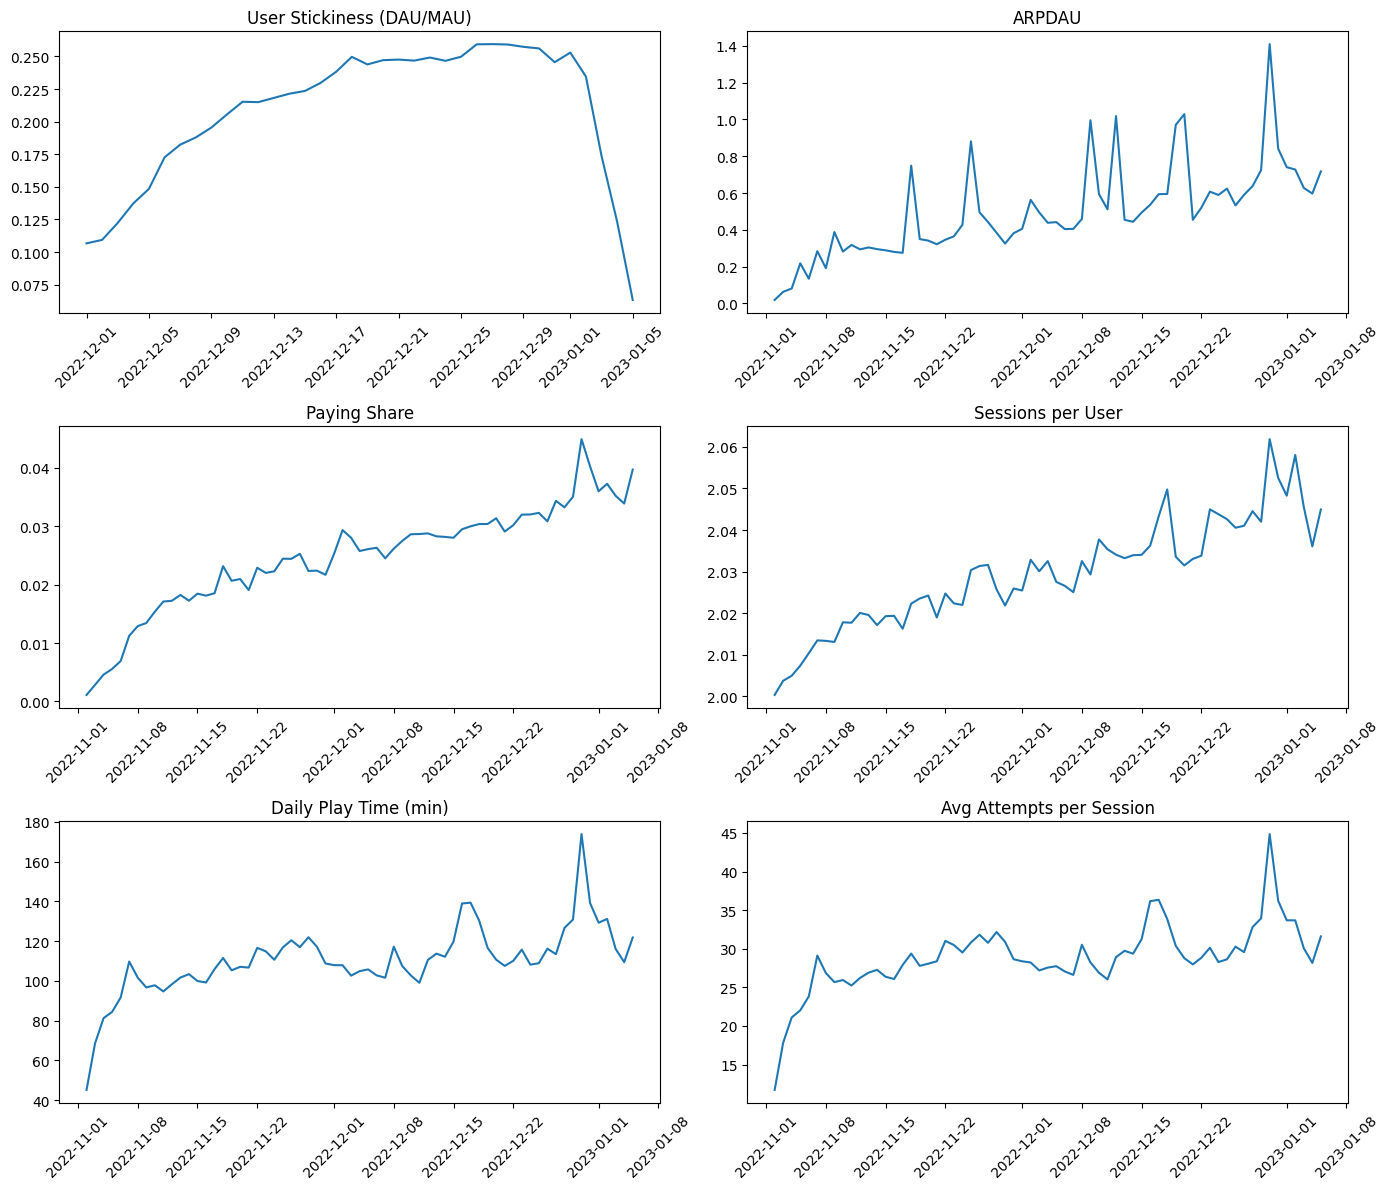

In [22]:
# ВИЗУАЛИЗАЦИЯ
# визуализация подневной динамики
# визуализация подневной динамики
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

axes[0, 0].plot(stickiness.index, stickiness.values)
axes[0, 0].set_title('User Stickiness (DAU/MAU)')
axes[0, 0].tick_params(axis='x', rotation=45)

axes[0, 1].plot(arpdau.index, arpdau.values)
axes[0, 1].set_title('ARPDAU')
axes[0, 1].tick_params(axis='x', rotation=45)

axes[1, 0].plot(paying_share.index, paying_share.values)
axes[1, 0].set_title('Paying Share')
axes[1, 0].tick_params(axis='x', rotation=45)

axes[1, 1].plot(sessions_per_user.index, sessions_per_user.values)
axes[1, 1].set_title('Sessions per User')
axes[1, 1].tick_params(axis='x', rotation=45)

axes[2, 0].plot(daily_play_time.index, daily_play_time.values)
axes[2, 0].set_title('Daily Play Time (min)')
axes[2, 0].tick_params(axis='x', rotation=45)

axes[2, 1].plot(avg_attempts.index, avg_attempts.values)
axes[2, 1].set_title('Avg Attempts per Session')
axes[2, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 2. Ride hailing  — 2 балла
У вас есть данные из приложения такси. Рассчитайте и визуализируйте:
- Ride Completion Rate — CR из заказа в завершенную поездку
- Acceptance Rate — доля заказов, принятых водителем (считаем, что приняты все заказы, кроме заказов со статусом 'No Driver Found')
- Cancellation Rate — доля отмененных заказов
- Rides per Driver — среднее число поездок на водителя
- Avg Ride Check — средний чек поездки
- Отношение RTA к ETA (что измеряет эта метрика?)

*Смотрим на подневную динамику

In [23]:
df_rh = pd.read_csv('/content/drive/MyDrive/hw_2_taxi.csv')

In [24]:
df_rh.head()

,date,time,order_uid,order_status,passenger_id,vehicle_type,pickup_location,drop_location,ETA,RTA,...,reason_for_cancelling_by_customer,cancelled_rides_by_driver,driver_cancellation_reason,incomplete_rides,incomplete_rides_reason,fare,ride_distance,driver_ratings,customer_rating,payment_method
0,2024-01-01,00:19:34,2a11faf27f77eae8,Completed,CID8362794,Bike,Udyog Vihar,Ambience Mall,9.0,10.8,...,NaN,NaN,NaN,NaN,NaN,99.0,37.98,4.8,4.8,Cash
1,2024-01-01,01:35:18,33ed1f6bad78bdc8,Completed,CID8300238,Go Mini,Basai Dhankot,Madipur,6.0,8.5,...,NaN,NaN,NaN,NaN,NaN,114.0,39.29,4.2,4.1,Uber Wallet
2,2024-01-01,01:37:50,e2fc1fc520e93b85,Cancelled by Driver,CID2030746,Go Sedan,Tughlakabad,Greater Kailash,6.0,7.4,...,NaN,1.0,More than permitted people in there,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2024-01-01,01:48:03,a130fd507acf7804,Cancelled by Driver,CID3231181,Auto,Palam Vihar,Kherki Daula Toll,5.0,NaN,...,NaN,1.0,Personal & Car related issues,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2024-01-01,01:49:56,cae2db8689a422fa,Cancelled by Driver,CID3381661,Go Sedan,Narsinghpur,Pulbangash,3.0,6.2,...,NaN,1.0,More than permitted people in there,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
df_rh.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 22 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   date                               150000 non-null  object 
 1   time                               150000 non-null  object 
 2   order_uid                          150000 non-null  object 
 3   order_status                       150000 non-null  object 
 4   passenger_id                       150000 non-null  object 
 5   vehicle_type                       150000 non-null  object 
 6   pickup_location                    150000 non-null  object 
 7   drop_location                      150000 non-null  object 
 8   ETA                                139500 non-null  float64
 9   RTA                                125764 non-null  float64
 10  driver_id                          139500 non-null  object 
 11  cancelled_rides_by_customer        1050

In [27]:
# привожу дату к формату
df_rh['date'] = pd.to_datetime(df_rh['date'])
df_rh

,date,time,order_uid,order_status,passenger_id,vehicle_type,pickup_location,drop_location,ETA,RTA,...,reason_for_cancelling_by_customer,cancelled_rides_by_driver,driver_cancellation_reason,incomplete_rides,incomplete_rides_reason,fare,ride_distance,driver_ratings,customer_rating,payment_method
0,2024-01-01,00:19:34,2a11faf27f77eae8,Completed,CID8362794,Bike,Udyog Vihar,Ambience Mall,9.0,10.8,...,NaN,NaN,NaN,NaN,NaN,99.0,37.98,4.8,4.8,Cash
1,2024-01-01,01:35:18,33ed1f6bad78bdc8,Completed,CID8300238,Go Mini,Basai Dhankot,Madipur,6.0,8.5,...,NaN,NaN,NaN,NaN,NaN,114.0,39.29,4.2,4.1,Uber Wallet
2,2024-01-01,01:37:50,e2fc1fc520e93b85,Cancelled by Driver,CID2030746,Go Sedan,Tughlakabad,Greater Kailash,6.0,7.4,...,NaN,1.0,More than permitted people in there,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2024-01-01,01:48:03,a130fd507acf7804,Cancelled by Driver,CID3231181,Auto,Palam Vihar,Kherki Daula Toll,5.0,NaN,...,NaN,1.0,Personal & Car related issues,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2024-01-01,01:49:56,cae2db8689a422fa,Cancelled by Driver,CID3381661,Go Sedan,Narsinghpur,Pulbangash,3.0,6.2,...,NaN,1.0,More than permitted people in there,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,2024-12-30,22:58:00,31b0887dbc04695a,Completed,CID6939658,Bike,DLF Phase 3,Okhla,5.0,6.9,...,NaN,NaN,NaN,NaN,NaN,440.0,12.85,4.4,4.8,UPI
149996,2024-12-30,23:03:14,8db62e93c09b5fae,Completed,CID9905090,eBike,Saket,Noida Sector 62,5.0,7.9,...,NaN,NaN,NaN,NaN,NaN,279.0,39.36,3.8,4.3,UPI
149997,2024-12-30,23:17:05,465afbdaa24fdbfa,Completed,CID4170406,Go Mini,GTB Nagar,Anand Vihar ISBT,8.0,9.9,...,NaN,NaN,NaN,NaN,NaN,1855.0,38.91,4.3,4.6,UPI
149998,2024-12-30,23:21:12,83debe1f3e652075,Completed,CID8938559,Uber XL,Ashram,Vasant Kunj,2.0,2.6,...,NaN,NaN,NaN,NaN,NaN,520.0,36.37,5.0,4.3,Uber Wallet


Описание данных (уникальный ключ order_uid)

- date — дата создания заказа
- time — время создания заказа
- order_uid — уникальный идентификатор заказа
- order_status — статус заказа
- passenger_id — уникальный идентификатор пассажира
- vehicle_type — тип транспорта
- pickup_location — место отправления
- drop_location — место назначения
- ETA — прогнозное время прибытия водителя на место отправления (estimated time of arrival)
- RTA — реальное время прибытия водителя на место отправления (real time of arrival)
- driver_id — уникальный идентификатор водителя
- cancelled_rides_by_customer — флаг отмены поездки пассажиром
- reason_for_cancelling_by_customer — причина отмены поездки пассажиром
- cancelled_rides_by_driver — флаг отмены поездки водителем
- driver_cancellation_reason — причина отмены поездки водителем
- incomplete_rides — флаг незавершенной поездки
- incomplete_rides_reason — причина незавершенной поездки
- fare — цена поездки
- ride_distance – расстояние поездки
- driver_ratings — рейтинг водителя
- customer_rating — рейтинг пассажира
- payment_method – способ оплаты

In [28]:
# your code is here
# 1. РАСЧЕТ Ride Completion Rate - CR из заказа в завершенную поездку
# общее число заказов в день
total = df_rh.groupby('date')['order_uid'].nunique()
total

,order_uid
date,
2024-01-01,414
2024-01-02,389
2024-01-03,384
2024-01-04,414
2024-01-05,416
...,...
2024-12-26,369
2024-12-27,431
2024-12-28,391


In [29]:
completed = df_rh[df_rh['order_status'] == 'Completed'].groupby('date')['order_uid'].nunique()
ride_completion_rate = completed/total
ride_completion_rate

,order_uid
date,
2024-01-01,0.606280
2024-01-02,0.616967
2024-01-03,0.638021
2024-01-04,0.613527
2024-01-05,0.617788
...,...
2024-12-26,0.658537
2024-12-27,0.614849
2024-12-28,0.641944


In [30]:
# 2. РАСЧЕТ Acceptance Rate - доля заказов, принятых водителем (считаем, что приняты все заказы, кроме заказов со статусом 'No Driver Found')
accepted = df_rh[df_rh['order_status'] != 'No Driver Found'].groupby('date')['order_uid'].nunique()
acceptance_rate = accepted/total
acceptance_rate

,order_uid
date,
2024-01-01,0.944444
2024-01-02,0.917738
2024-01-03,0.947917
2024-01-04,0.929952
2024-01-05,0.918269
...,...
2024-12-26,0.943089
2024-12-27,0.923434
2024-12-28,0.933504


In [32]:
# 3. РАСЧЕТ Cancellation Rate — доля отмененных заказов
cancelled = df_rh[df_rh['order_status'].str.contains('Cancelled', na=False)].groupby('date')['order_uid'].nunique()
cancellation_rate = cancelled/total
cancellation_rate

,order_uid
date,
2024-01-01,0.287440
2024-01-02,0.254499
2024-01-03,0.247396
2024-01-04,0.251208
2024-01-05,0.240385
...,...
2024-12-26,0.241192
2024-12-27,0.255220
2024-12-28,0.237852


In [33]:
# 4. РАСЧЕТ Rides per Driver — среднее число поездок на водителя
completed_rides = df_rh[df_rh['order_status'] == 'Completed']
rides_per_driver = completed_rides.groupby(['date', 'driver_id'])['order_uid'].nunique().groupby('date').mean()
rides_per_driver

,order_uid
date,
2024-01-01,3.921875
2024-01-02,4.137931
2024-01-03,4.224138
2024-01-04,4.163934
2024-01-05,4.079365
...,...
2024-12-26,3.983607
2024-12-27,4.568966
2024-12-28,4.114754


In [35]:
# 5. РАСЧЕТ Avg Ride Check — средний чек поездки
avg_ride_check = completed_rides.groupby('date')['fare'].mean()
avg_ride_check

,fare
date,
2024-01-01,459.163347
2024-01-02,444.033333
2024-01-03,435.673469
2024-01-04,419.291339
2024-01-05,471.505837
...,...
2024-12-26,472.818930
2024-12-27,483.271698
2024-12-28,676.314741


In [38]:
# 6. РАСЧЕТ Отношение RTA к ETA (что измеряет эта метрика?)
df_rh['rta_eta_ratio'] = df_rh['RTA']/df_rh['ETA']
rta_eta = df_rh.groupby('date')['rta_eta_ratio'].mean()
rta_eta.sort_values(ascending = True)

,rta_eta_ratio
date,
2024-02-21,1.282322
2024-04-23,1.287571
2024-03-19,1.290279
2024-07-15,1.293410
2024-04-04,1.296475
...,...
2024-07-22,1.364036
2024-04-29,1.365132
2024-01-24,1.369351


Считаю так: сначала отношение для каждого заказа, потом среднее по дню. Эта метрика показывает точность прогноза времени прибытия: если > 1, водители опаздывают; если < 1 - приезжают раньше.

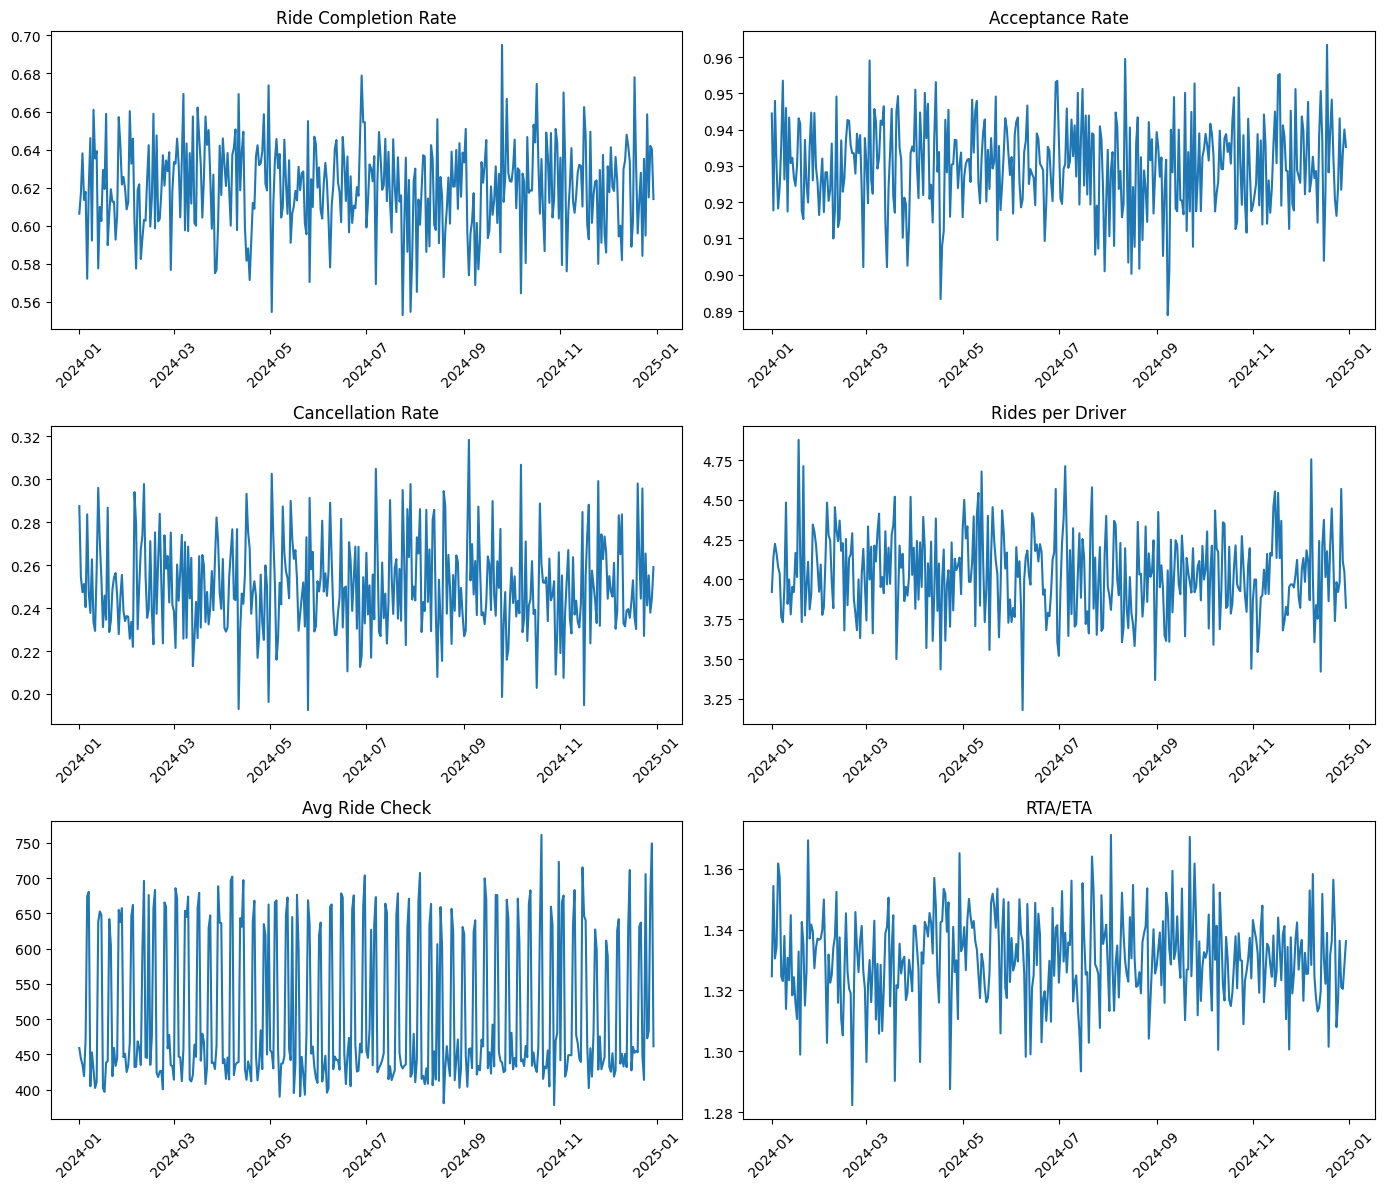

In [39]:
# ВИЗУАЛИЗАЦИЯ
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

axes[0, 0].plot(ride_completion_rate.index, ride_completion_rate.values)
axes[0, 0].set_title('Ride Completion Rate')
axes[0, 0].tick_params(axis='x', rotation=45)

axes[0, 1].plot(acceptance_rate.index, acceptance_rate.values)
axes[0, 1].set_title('Acceptance Rate')
axes[0, 1].tick_params(axis='x', rotation=45)

axes[1, 0].plot(cancellation_rate.index, cancellation_rate.values)
axes[1, 0].set_title('Cancellation Rate')
axes[1, 0].tick_params(axis='x', rotation=45)

axes[1, 1].plot(rides_per_driver.index, rides_per_driver.values)
axes[1, 1].set_title('Rides per Driver')
axes[1, 1].tick_params(axis='x', rotation=45)

axes[2, 0].plot(avg_ride_check.index, avg_ride_check.values)
axes[2, 0].set_title('Avg Ride Check')
axes[2, 0].tick_params(axis='x', rotation=45)

axes[2, 1].plot(rta_eta.index, rta_eta.values)
axes[2, 1].set_title('RTA/ETA')
axes[2, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Case Study. Запуск подкастов в стриминговом сервисе 🎧

**Легенда**  
Вы работаете продуктовым аналитиком в музыкальном стриминговом сервисе. Недавно в продукте запустился раздел с подкастами. Команда, отвечающая за запуск, хочет понять, стоит ли масштабировать и продвигать этот формат.

In [2]:
df_music_logs = pd.read_parquet('hw_2_streaming_logs.pqt')
df_music_subs = pd.read_parquet('hw_2_streaming_subs.pqt')

In [3]:
df_music_logs.head()

,datetime,uid,item_id,played_ratio_pct,track_length_seconds,content_type,is_first_date
0,2024-01-13 10:00:00,468300,7400764,100,225,music,0.0
1,2024-01-13 10:00:05,347600,3415205,100,250,music,0.0
2,2024-01-13 10:00:10,942900,6728180,1,270,music,0.0
3,2024-01-13 10:00:15,243500,5283544,100,195,music,0.0
4,2024-01-13 10:00:15,12700,8932363,100,245,music,0.0


In [4]:
df_music_logs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46384540 entries, 0 to 46384539
Data columns (total 7 columns):
 #   Column                Dtype         
---  ------                -----         
 0   datetime              datetime64[ns]
 1   uid                   uint32        
 2   item_id               uint32        
 3   played_ratio_pct      uint16        
 4   track_length_seconds  uint32        
 5   content_type          object        
 6   is_first_date         float64       
dtypes: datetime64[ns](1), float64(1), object(1), uint16(1), uint32(3)
memory usage: 1.6+ GB


In [7]:
# добавляю периоды
df_music_logs['date'] = df_music_logs['datetime'].dt.date
df_music_logs['week'] = df_music_logs['datetime'].dt.to_period('W').dt.start_time
df_music_logs['month'] = df_music_logs['datetime'].dt.to_period('M').dt.start_time
df_music_logs

,datetime,uid,item_id,played_ratio_pct,track_length_seconds,content_type,is_first_date,date,week,month
0,2024-01-13 10:00:00,468300,7400764,100,225,music,0.0,2024-01-13,2024-01-08,2024-01-01
1,2024-01-13 10:00:05,347600,3415205,100,250,music,0.0,2024-01-13,2024-01-08,2024-01-01
2,2024-01-13 10:00:10,942900,6728180,1,270,music,0.0,2024-01-13,2024-01-08,2024-01-01
3,2024-01-13 10:00:15,243500,5283544,100,195,music,0.0,2024-01-13,2024-01-08,2024-01-01
4,2024-01-13 10:00:15,12700,8932363,100,245,music,0.0,2024-01-13,2024-01-08,2024-01-01
...,...,...,...,...,...,...,...,...,...,...
46384535,2024-11-09 08:13:15,554500,1011428,3,115,music,0.0,2024-11-09,2024-11-04,2024-11-01
46384536,2024-11-09 08:13:15,190700,875069,0,235,music,0.0,2024-11-09,2024-11-04,2024-11-01
46384537,2024-11-09 08:13:20,144700,6281650,6,205,music,0.0,2024-11-09,2024-11-04,2024-11-01
46384538,2024-11-09 08:13:20,687600,2092880,12,130,music,0.0,2024-11-09,2024-11-04,2024-11-01


In [8]:
df_music_subs.head()

,uid,start_date,end_date
0,600,2024-08-08,NaT
1,700,2024-03-29,NaT
2,800,2024-06-13,NaT
3,1100,2024-11-19,NaT
4,1400,2024-12-01,NaT


In [9]:
df_music_subs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3603 entries, 0 to 3602
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   uid         3603 non-null   int64         
 1   start_date  3603 non-null   datetime64[ns]
 2   end_date    247 non-null    datetime64[ns]
dtypes: datetime64[ns](2), int64(1)
memory usage: 84.6 KB


Описание данных hw_2_streaming_logs:

- datetime — дата-время взаимодействия с контентом
- uid — уникальный идентификатор пользователя
- item_id — уникальный идентификатор трека/эпизода
- played_ratio_pct — процент от длительности, который был воспроизведен
- track_length_seconds – длина трека/эпизода в секундах
- content_type — тип контента: музыка или подкаст
- is_first_date — флаг, является ли эта дата первой для пользователя в продукте

Описание данных hw_2_streaming_subs:

- uid — уникальный идентификатор пользователя
- start_date — дата начала подписки
- end_date — дата окончания подписки

In [10]:
# границы полных периодов
max_date = df_music_logs['datetime'].max()
min_date = df_music_logs['datetime'].min()

last_week_end = max_date.to_period('W').end_time.date()
last_full_week = max_date.to_period('W').start_time if max_date.date() == last_week_end else (max_date.to_period('W') - 1).start_time

last_full_month = (max_date.to_period('M') - 1).start_time

first_full_week = min_date.to_period('W').start_time
if min_date.date() != first_full_week.date():
    first_full_week = (min_date.to_period('W') + 1).start_time

first_full_month = min_date.to_period('M').start_time
if min_date.date() != first_full_month.date():
    first_full_month = (min_date.to_period('M') + 1).start_time

print('Первая полная неделя:', first_full_week)
print('Последняя полная неделя:', last_full_week)
print('Первый полный месяц:', first_full_month)
print('Последний полный месяц:', last_full_month)

Первая полная неделя: 2024-01-15 00:00:00
Последняя полная неделя: 2024-10-28 00:00:00
Первый полный месяц: 2024-02-01 00:00:00
Последний полный месяц: 2024-10-01 00:00:00


### 3. Метрики роста  — 2 балла

Рассчитайте и визуализируйте:
- DAU, MAU, WAU;
- Количество новых премиум-подписчиков (за неделю и месяц);
- Проникновение подкастов — долю юзеров, послушавших подкаст хотя бы раз (за неделю и месяц).

Сделайте выводы:
- Есть ли выраженный тренд?
- Нет ли подозрений, что с раскаткой раздела что-то могло пойти не так (изменение тренда, выраженные ступеньки)?
- Как выглядит адопшен? Можно ли предположить наличие каких-то эффектов в пользовательском взаимодействии с новым разделом?

In [11]:
# your code is here
#1. РАСЧЕТ DAU, MAU, WAU;
dau = df_music_logs.groupby('date')['uid'].nunique()
dau

date
2024-01-13    1985
2024-01-14    2547
2024-01-15    2342
2024-01-16    2471
2024-01-17    2549
              ... 
2024-11-05    4777
2024-11-06    4818
2024-11-07    4935
2024-11-08    4913
2024-11-09    3121
Name: uid, Length: 302, dtype: int64

In [12]:
# обрезаю неполные периоды
dau = dau[(pd.to_datetime(dau.index) >= first_full_week) & (pd.to_datetime(dau.index) <= last_full_week + pd.Timedelta(days=6))]

In [13]:
wau = df_music_logs.groupby('week')['uid'].nunique()
wau

week
2024-01-08    2973
2024-01-15    4164
2024-01-22    4253
2024-01-29    4319
2024-02-05    4368
2024-02-12    4384
2024-02-19    4505
2024-02-26    4549
2024-03-04    4610
2024-03-11    4660
2024-03-18    4761
2024-03-25    4868
2024-04-01    4921
2024-04-08    4997
2024-04-15    5022
2024-04-22    5108
2024-04-29    5040
2024-05-06    5164
2024-05-13    5229
2024-05-20    5287
2024-05-27    5378
2024-06-03    5366
2024-06-10    5358
2024-06-17    5429
2024-06-24    5500
2024-07-01    5537
2024-07-08    5648
2024-07-15    5668
2024-07-22    5789
2024-07-29    5809
2024-08-05    5953
2024-08-12    6088
2024-08-19    6277
2024-08-26    6417
2024-09-02    6545
2024-09-09    6718
2024-09-16    6837
2024-09-23    6954
2024-09-30    7089
2024-10-07    7260
2024-10-14    7427
2024-10-21    7720
2024-10-28    8091
2024-11-04    7573
Name: uid, dtype: int64

In [14]:
wau = wau[(wau.index >= first_full_week) & (wau.index <= last_full_week)]

In [15]:
mau = df_music_logs.groupby('month')['uid'].nunique()
mau

month
2024-01-01    4828
2024-02-01    5299
2024-03-01    5666
2024-04-01    5961
2024-05-01    6236
2024-06-01    6460
2024-07-01    6844
2024-08-01    7376
2024-09-01    8050
2024-10-01    8846
2024-11-01    8328
Name: uid, dtype: int64

In [16]:
mau = mau[(mau.index >= first_full_month) & (mau.index <= last_full_month)]

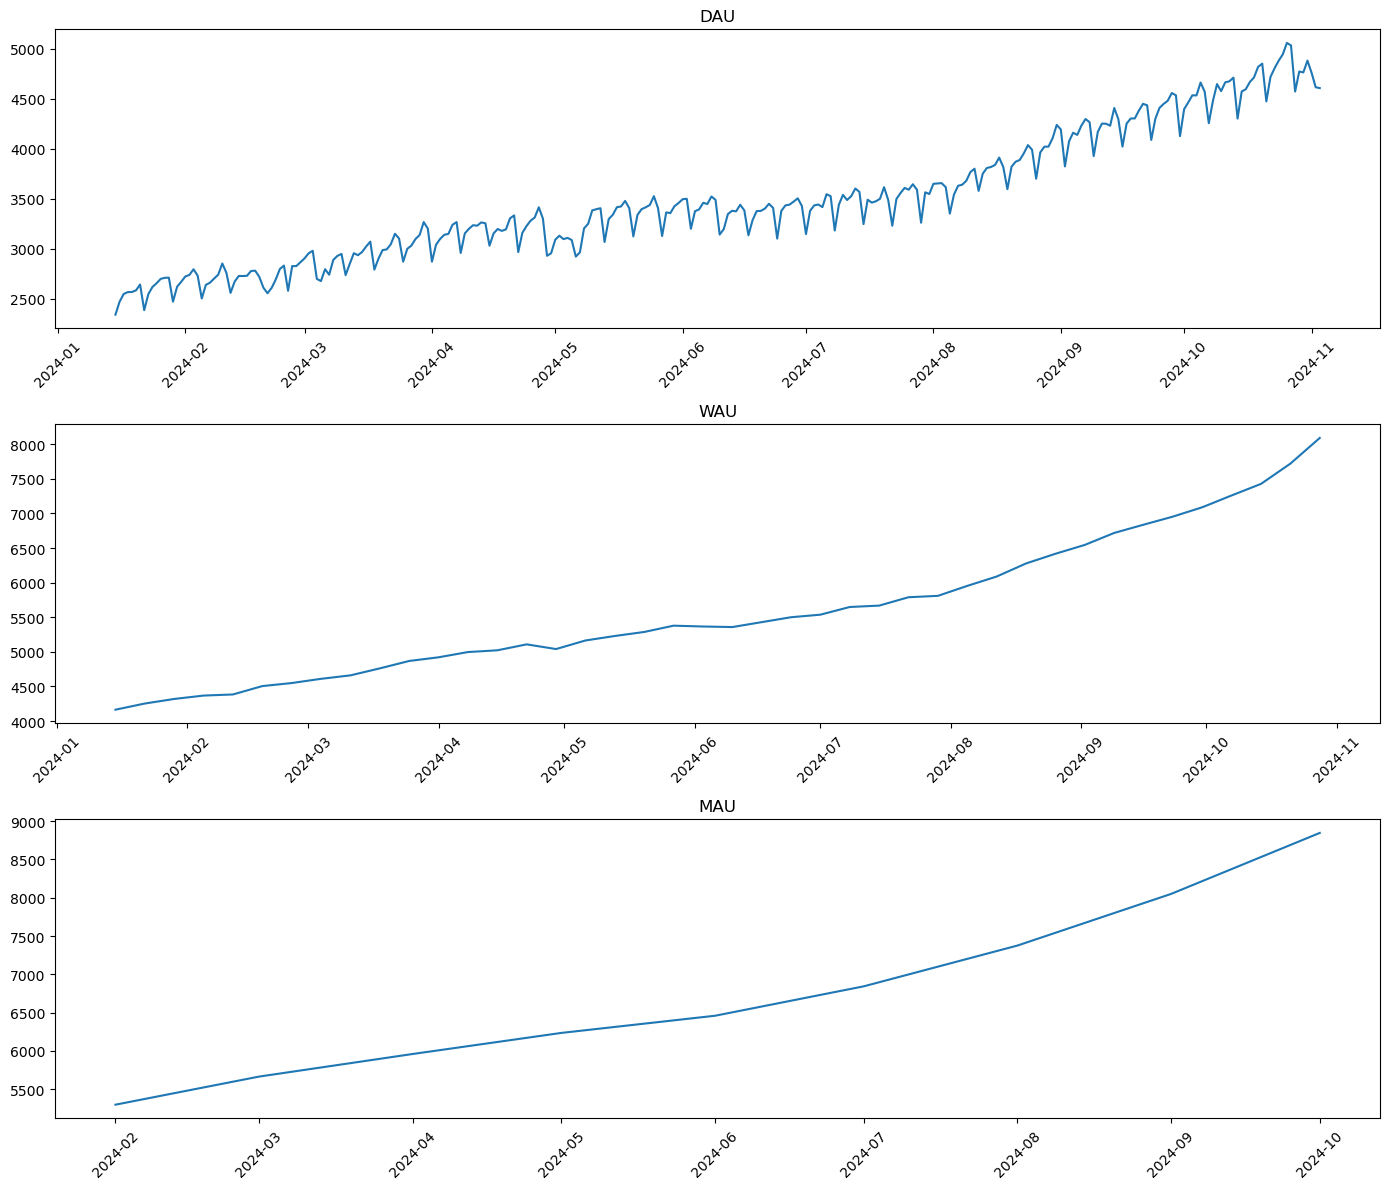

In [17]:
# Визуализация: DAU/WAU/MAU
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

axes[0].plot(dau.index, dau.values)
axes[0].set_title('DAU')
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(wau.index, wau.values)
axes[1].set_title('WAU')
axes[1].tick_params(axis='x', rotation=45)

axes[2].plot(mau.index, mau.values)
axes[2].set_title('MAU')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [19]:
# 2. Количество новых премиум-подписчиков (за неделю и месяц);
# новые премиум-подписчики (все подписки = премиум)
df_music_subs['week'] = df_music_subs['start_date'].dt.to_period('W').dt.start_time
df_music_subs['month'] = df_music_subs['start_date'].dt.to_period('M').dt.start_time

In [20]:
new_subs_week = df_music_subs.groupby('week')['uid'].nunique()
new_subs_week

week
2024-01-08     9
2024-01-15    49
2024-01-22    63
2024-01-29    42
2024-02-05    57
2024-02-12    54
2024-02-19    67
2024-02-26    65
2024-03-04    62
2024-03-11    59
2024-03-18    65
2024-03-25    59
2024-04-01    64
2024-04-08    71
2024-04-15    62
2024-04-22    72
2024-04-29    62
2024-05-06    63
2024-05-13    71
2024-05-20    75
2024-05-27    82
2024-06-03    72
2024-06-10    70
2024-06-17    70
2024-06-24    82
2024-07-01    66
2024-07-08    65
2024-07-15    79
2024-07-22    69
2024-07-29    84
2024-08-05    73
2024-08-12    77
2024-08-19    73
2024-08-26    76
2024-09-02    74
2024-09-09    81
2024-09-16    77
2024-09-23    72
2024-09-30    82
2024-10-07    93
2024-10-14    89
2024-10-21    68
2024-10-28    72
2024-11-04    77
2024-11-11    87
2024-11-18    76
2024-11-25    83
2024-12-02    65
2024-12-09    86
2024-12-16    95
2024-12-23    70
2024-12-30    27
Name: uid, dtype: int64

In [21]:
new_subs_week = new_subs_week[(new_subs_week.index >= first_full_week) & (new_subs_week.index <= last_full_week)]

In [22]:
new_subs_month = df_music_subs.groupby('month')['uid'].nunique()
new_subs_month

month
2024-01-01    147
2024-02-01    232
2024-03-01    272
2024-04-01    290
2024-05-01    300
2024-06-01    326
2024-07-01    311
2024-08-01    344
2024-09-01    322
2024-10-01    355
2024-11-01    349
2024-12-01    355
Name: uid, dtype: int64

In [23]:
new_subs_month = new_subs_month[(new_subs_month.index >= first_full_month) & (new_subs_month.index <= last_full_month)]

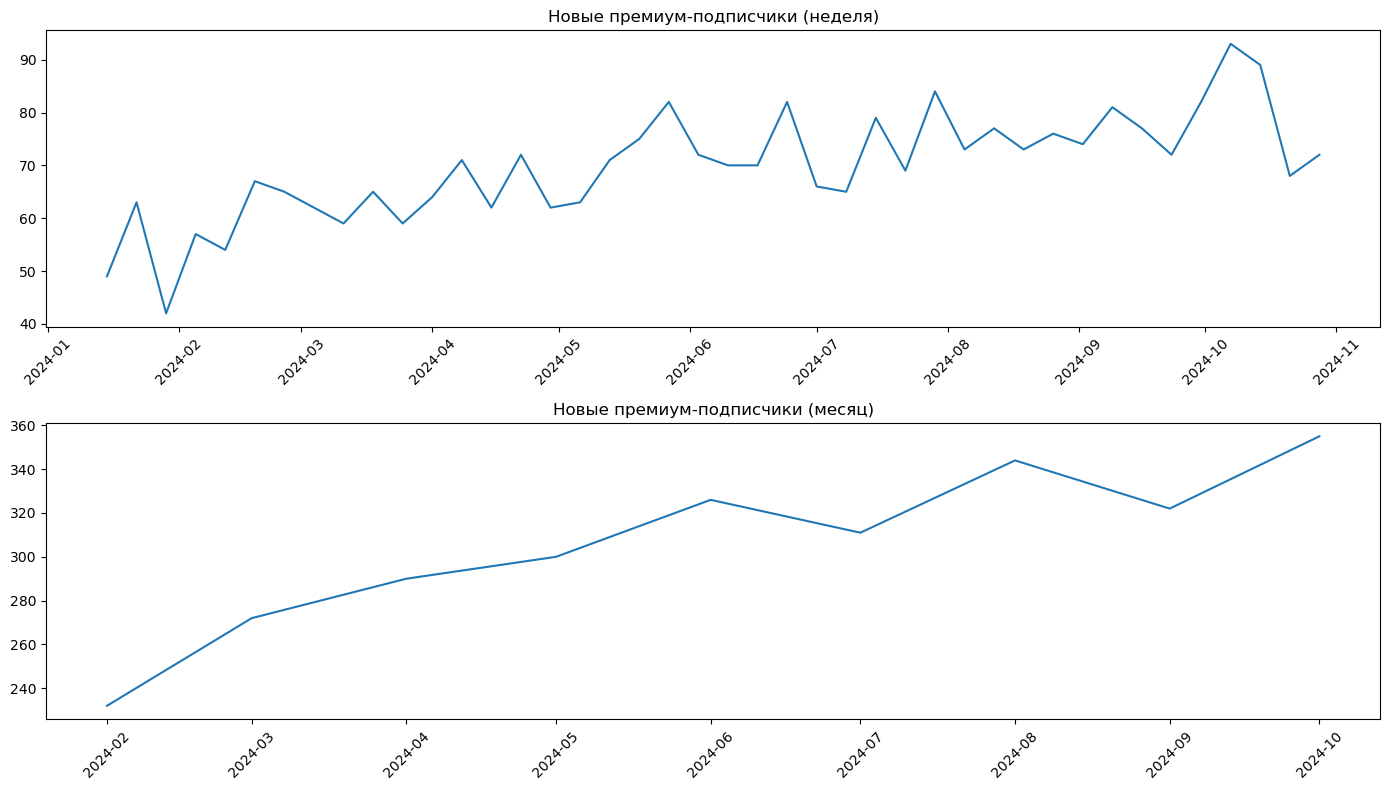

In [24]:
# Визуализация: новые подписчики
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(new_subs_week.index, new_subs_week.values)
axes[0].set_title('Новые премиум-подписчики (неделя)')
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(new_subs_month.index, new_subs_month.values)
axes[1].set_title('Новые премиум-подписчики (месяц)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [25]:
# 3. Проникновение подкастов — долю юзеров, послушавших подкаст хотя бы раз (за неделю и месяц).
podcast_users = df_music_logs[df_music_logs['content_type'] == 'podcast']
podcast_users

,datetime,uid,item_id,played_ratio_pct,track_length_seconds,content_type,is_first_date,date,week,month
32526095,2024-09-01 00:01:00,700700,1530256,3,1095,podcast,0.0,2024-09-01,2024-08-26,2024-09-01
32526396,2024-09-01 00:02:25,531600,6834933,2,1475,podcast,0.0,2024-09-01,2024-08-26,2024-09-01
32526667,2024-09-01 00:04:05,852400,801028,100,880,podcast,0.0,2024-09-01,2024-08-26,2024-09-01
32527513,2024-09-01 00:08:10,261000,965957,92,860,podcast,0.0,2024-09-01,2024-08-26,2024-09-01
32527516,2024-09-01 00:08:10,261000,6653487,1,935,podcast,0.0,2024-09-01,2024-08-26,2024-09-01
...,...,...,...,...,...,...,...,...,...,...
46383752,2024-11-09 08:03:10,171800,4899292,5,1530,podcast,0.0,2024-11-09,2024-11-04,2024-11-01
46383872,2024-11-09 08:04:55,171800,2232885,0,1560,podcast,0.0,2024-11-09,2024-11-04,2024-11-01
46383930,2024-11-09 08:05:35,171800,7704531,6,630,podcast,0.0,2024-11-09,2024-11-04,2024-11-01
46384065,2024-11-09 08:07:25,291500,947845,100,1375,podcast,0.0,2024-11-09,2024-11-04,2024-11-01


In [26]:
podcast_pen_week = podcast_users.groupby('week')['uid'].nunique()/df_music_logs.groupby('week')['uid'].nunique()
podcast_pen_week

week
2024-01-08         NaN
2024-01-15         NaN
2024-01-22         NaN
2024-01-29         NaN
2024-02-05         NaN
2024-02-12         NaN
2024-02-19         NaN
2024-02-26         NaN
2024-03-04         NaN
2024-03-11         NaN
2024-03-18         NaN
2024-03-25         NaN
2024-04-01         NaN
2024-04-08         NaN
2024-04-15         NaN
2024-04-22         NaN
2024-04-29         NaN
2024-05-06         NaN
2024-05-13         NaN
2024-05-20         NaN
2024-05-27         NaN
2024-06-03         NaN
2024-06-10         NaN
2024-06-17         NaN
2024-06-24         NaN
2024-07-01         NaN
2024-07-08         NaN
2024-07-15         NaN
2024-07-22         NaN
2024-07-29         NaN
2024-08-05         NaN
2024-08-12         NaN
2024-08-19         NaN
2024-08-26    0.028518
2024-09-02    0.122536
2024-09-09    0.123400
2024-09-16    0.142021
2024-09-23    0.136037
2024-09-30    0.125406
2024-10-07    0.124380
2024-10-14    0.133163
2024-10-21    0.133290
2024-10-28    0.118774
2024-1

In [27]:
podcast_pen_week = podcast_pen_week[(podcast_pen_week.index >= first_full_week) & (podcast_pen_week.index <= last_full_week)]

In [28]:
podcast_pen_month = podcast_users.groupby('month')['uid'].nunique()/df_music_logs.groupby('month')['uid'].nunique()
podcast_pen_month

month
2024-01-01         NaN
2024-02-01         NaN
2024-03-01         NaN
2024-04-01         NaN
2024-05-01         NaN
2024-06-01         NaN
2024-07-01         NaN
2024-08-01         NaN
2024-09-01    0.286335
2024-10-01    0.277979
2024-11-01    0.132445
Name: uid, dtype: float64

In [29]:
podcast_pen_month = podcast_pen_month[(podcast_pen_month.index >= first_full_month) & (podcast_pen_month.index <= last_full_month)]

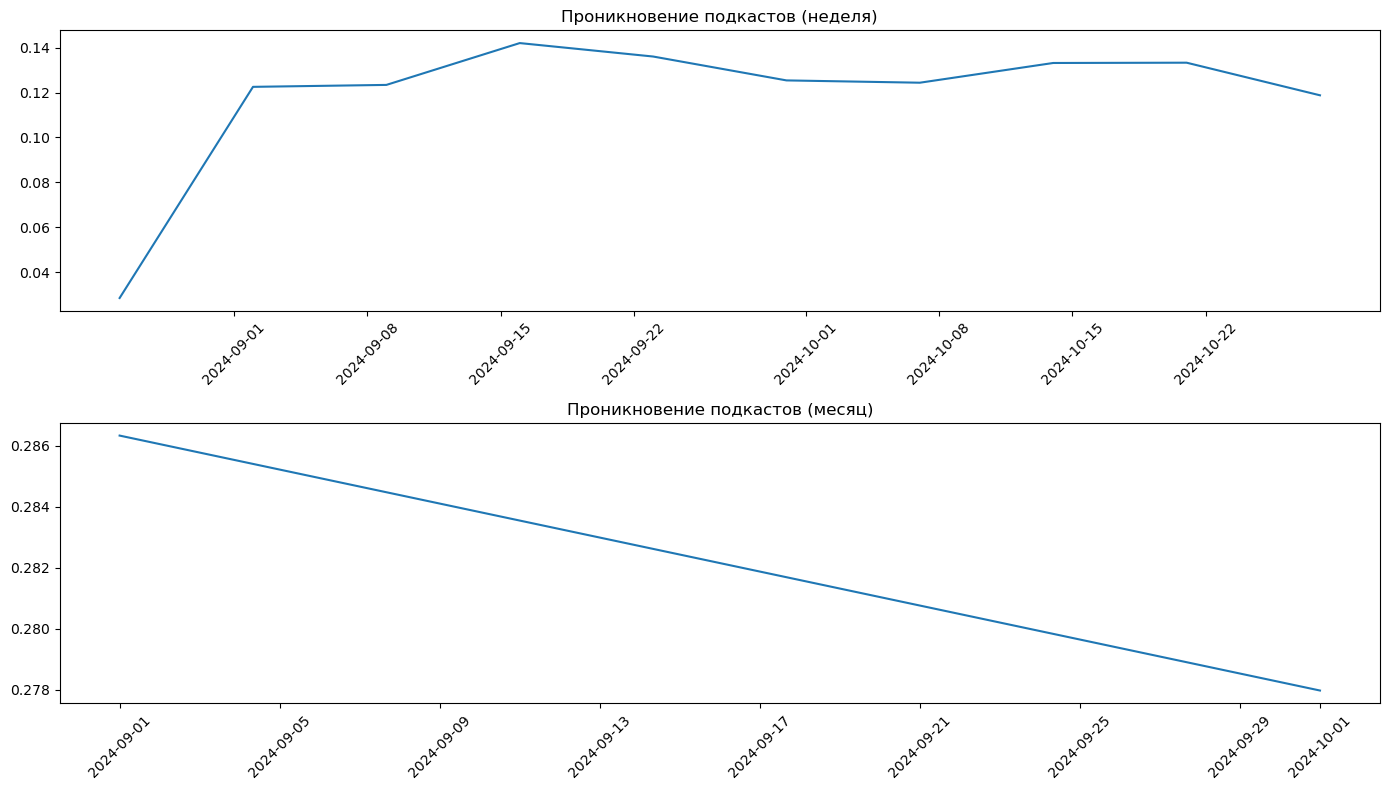

In [30]:
# Визуализация: проникновение подкастов
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(podcast_pen_week.index, podcast_pen_week.values)
axes[0].set_title('Проникновение подкастов (неделя)')
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(podcast_pen_month.index, podcast_pen_month.values)
axes[1].set_title('Проникновение подкастов (месяц)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**1. Есть ли выраженный тренд?**
Да, растут DAU, WAU, MAU, подписчики тоже растут, но примерно с мая колеблется в между значениями

**2. Нет ли подозрений, что с раскаткой что-то пошло не так?**
На графике проникновения подкастов (неделя) видна резкая ступенька вверх в начале сентября проникновение растет, что является моментом раскатки раздела. Дальше рост, но потом снижение к ноябрю. Каких-то явных провалов нет, раздел запустился нормально. Но вот после пика проникновение снижается, удержать интерес на пиковом уровне не удается.

**3. Как выглядит адопшен? Можно ли предположить наличие каких-то эффектов в пользовательском взаимодействии с новым разделом?**
В момент запуска скачок интереса, дальше пик, снижение. Скорее всего, эффект новизны: пользователи попробовали новый формат, но удержанин слабое


По графикам. Последние точки на всех графиках (конец ноября) - неполные периоды, их можно отрезать (неделя - последняя неполная неделя, месяц - обрезка ноября)

### 4. Метрики продукта (шаг 1)  — 2 балла

Рассчитайте и визуализируйте как для всех пользователей в совокупности, так и для сегментов пользователей в разрезе — сделали / не сделали взаимодействие с подкастами (грубо говоря разделяем юзеров на тех, кто слушает только музыку и тех, кто слушает еще и подкасты):
1. Среднее время прослушивания на пользователя.
2. Среднее число треков/эпизодов на пользователя (среднее число item_id). Посчитайте метрику, как от уникальных, так и от не уникальных item_id. Подумайте, что показывает каждая из них?
3. Долю премиум-подписчиков. Обратите внимание, что нам нужна активная подписка, если пользователь отписался в том же периоде, что подписался, мы больше не считаем подписку активной.

Рассчитайте и визуализируйте как по всем item_id, так и в разрезе типов контента:
- Долю дослушанных треков/эпизодов до конца. Обратите внимание, данная метрика уже не пользовательская.

Периоды — неделя и месяц. Неполные периоды нужно обрезать, если они мешают чтению графиков.   
Признак взаимодействия присвайвайте только для периода, когда оно действительно было.   
Для месячной динамики метрик по признаку взаимодействия с подкастами у вас получится всего 2 точки, такая визуализая тоже полезна, она сглаживает недельные колебания и помогает оценивать тренд в масштабе года.

Сделайте выводы:
- Есть ли выраженный тренд?
- Изменилась ли метрика после запуска подкастов?
- Отличается ли метрика сегмента, взаимодействовавшего с подкастами, от тех, кто слушал только музыку? (будьте аккуратны с выводами в этом пункте, мы не проверяем изменение на каузальность, поэтому не можем быть уверены где причина, а где следствие)
- Есть ли отличия между типами контента?

*За взаимодействие с подкастами давайте считать только прослушивание >= 30% или более 2х минут контента*

In [31]:
# your code is here
# прослушанные секунды
df_music_logs['played_seconds'] = df_music_logs['track_length_seconds'] * df_music_logs['played_ratio_pct']/100

In [32]:
# флаг взаимодействия с подкастами: >= 30% от длины подкаста ИЛИ > 2 минут
df_music_logs['podcast_interaction'] = (
    (df_music_logs['content_type'] == 'podcast') &
    (
        (df_music_logs['played_ratio_pct'] >= 30) |
        (df_music_logs['played_seconds'] > 120)
    )
)

In [33]:
# ОБРЕЗКА: отдельно для недель и месяцев
df_week = df_music_logs[
    (df_music_logs['week'] >= first_full_week) &
    (df_music_logs['week'] <= last_full_week)
].copy()

df_month = df_music_logs[
    (df_music_logs['month'] >= first_full_month) &
    (df_music_logs['month'] <= last_full_month)
].copy()

In [34]:
# флаг пересчитывается на каждом периоде: было ли у юзера взаимодействие на этой неделе/месяце
# неделя
week_interaction = df_week.groupby(['week', 'uid'])['podcast_interaction'].max().reset_index()
week_interaction.columns = ['week', 'uid', 'listened_podcast']
week_interaction

,week,uid,listened_podcast
0,2024-01-15,100,False
1,2024-01-15,700,False
2,2024-01-15,800,False
3,2024-01-15,900,False
4,2024-01-15,1300,False
...,...,...,...
235062,2024-10-28,999600,False
235063,2024-10-28,999700,False
235064,2024-10-28,999800,False
235065,2024-10-28,999900,False


In [35]:
# месяц
month_interaction = df_month.groupby(['month', 'uid'])['podcast_interaction'].max().reset_index()
month_interaction.columns = ['month', 'uid', 'listened_podcast']
month_interaction

,month,uid,listened_podcast
0,2024-02-01,100,False
1,2024-02-01,300,False
2,2024-02-01,600,False
3,2024-02-01,700,False
4,2024-02-01,800,False
...,...,...,...
60733,2024-10-01,999600,False
60734,2024-10-01,999700,False
60735,2024-10-01,999800,False
60736,2024-10-01,999900,False


In [36]:
# присоединяю флаги к логам
df_week = df_week.merge(week_interaction, on=['week', 'uid'], how='left')
df_month = df_month.merge(month_interaction, on=['month', 'uid'], how='left')

In [37]:
# 1. Среднее время прослушивания на пользователя
# по неделям все пользователи
weekly_listen_time_all = df_week.groupby('week')['played_seconds'].sum()/df_week.groupby('week')['uid'].nunique()
weekly_listen_time_all

week
2024-01-15    24533.040130
2024-01-22    24741.731390
2024-01-29    24924.053265
2024-02-05    24549.660508
2024-02-12    25022.672936
2024-02-19    23713.303840
2024-02-26    25152.902968
2024-03-04    24481.488568
2024-03-11    25248.827811
2024-03-18    25204.038028
2024-03-25    24691.370008
2024-04-01    25285.478216
2024-04-08    25876.952101
2024-04-15    25490.823517
2024-04-22    25204.220478
2024-04-29    24498.001012
2024-05-06    24376.567409
2024-05-13    25441.880092
2024-05-20    25814.658483
2024-05-27    25424.203626
2024-06-03    25908.154268
2024-06-10    25577.688251
2024-06-17    24793.574028
2024-06-24    24923.413864
2024-07-01    24907.016561
2024-07-08    25228.933463
2024-07-15    24664.910524
2024-07-22    24855.277595
2024-07-29    24860.880565
2024-08-05    25093.304275
2024-08-12    25467.418068
2024-08-19    25210.479489
2024-08-26    25248.197140
2024-09-02    25559.925974
2024-09-09    25475.201474
2024-09-16    25189.124163
2024-09-23    25323.911

In [38]:
# по неделям по сегментам
weekly_listen_time_seg = df_week.groupby(['week', 'listened_podcast'])['played_seconds'].sum()/df_week.groupby(['week', 'listened_podcast'])['uid'].nunique()
weekly_listen_time_seg

week        listened_podcast
2024-01-15  False               24533.040130
2024-01-22  False               24741.731390
2024-01-29  False               24924.053265
2024-02-05  False               24549.660508
2024-02-12  False               25022.672936
2024-02-19  False               23713.303840
2024-02-26  False               25152.902968
2024-03-04  False               24481.488568
2024-03-11  False               25248.827811
2024-03-18  False               25204.038028
2024-03-25  False               24691.370008
2024-04-01  False               25285.478216
2024-04-08  False               25876.952101
2024-04-15  False               25490.823517
2024-04-22  False               25204.220478
2024-04-29  False               24498.001012
2024-05-06  False               24376.567409
2024-05-13  False               25441.880092
2024-05-20  False               25814.658483
2024-05-27  False               25424.203626
2024-06-03  False               25908.154268
2024-06-10  False         

In [39]:
# по месяцам все
monthly_listen_time_all = df_month.groupby('month')['played_seconds'].sum()/df_month.groupby('month')['uid'].nunique()
monthly_listen_time_all

month
2024-02-01    85103.882912
2024-03-01    92068.251006
2024-04-01    91101.362783
2024-05-01    93368.610632
2024-06-01    91105.919226
2024-07-01    91127.898816
2024-08-01    92956.257680
2024-09-01    91186.750025
2024-10-01    94593.024463
dtype: float64

In [40]:
# по месяцам по сегментам
monthly_listen_time_seg = df_month.groupby(['month', 'listened_podcast'])['played_seconds'].sum()/df_month.groupby(['month', 'listened_podcast'])['uid'].nunique()
monthly_listen_time_seg

month       listened_podcast
2024-02-01  False                85103.882912
2024-03-01  False                92068.251006
2024-04-01  False                91101.362783
2024-05-01  False                93368.610632
2024-06-01  False                91105.919226
2024-07-01  False                91127.898816
2024-08-01  False                92956.257680
2024-09-01  False                82074.654407
            True                134846.143417
2024-10-01  False                85182.529551
            True                139062.942492
dtype: float64

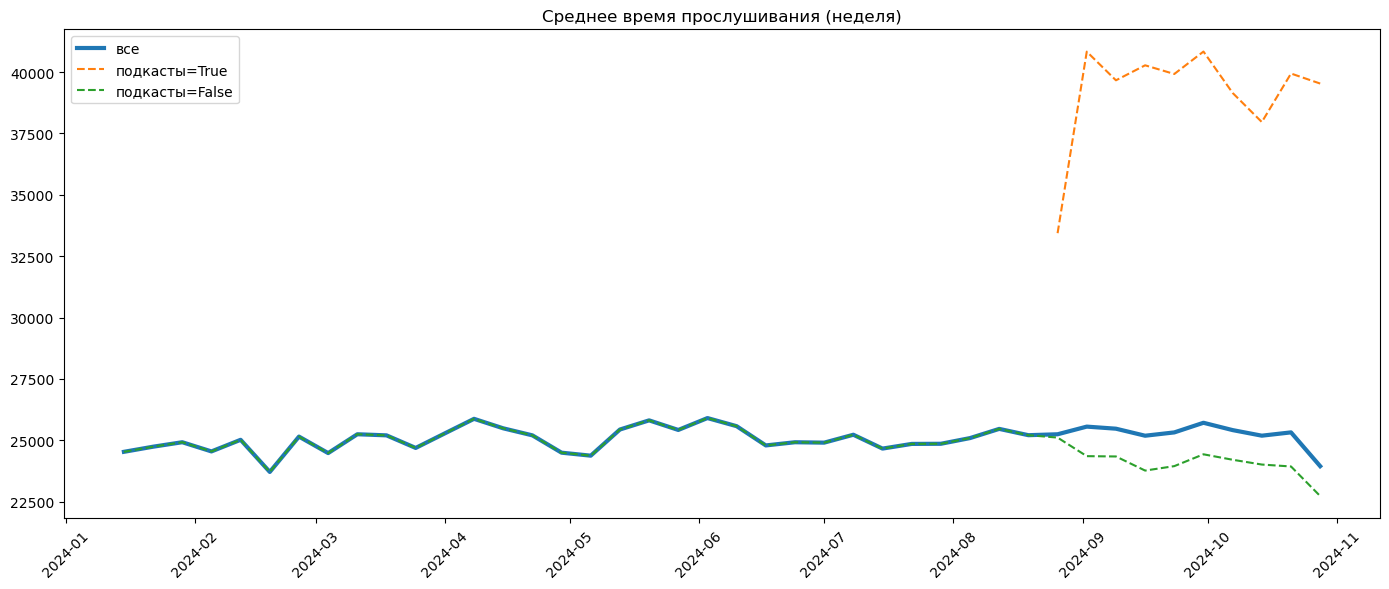

In [42]:
# ВИЗУАЛИЗАЦИЯ СРЕДНЕГО ВРЕМЕНИ ПРОСЛУШИВАНИЯ
# неделя
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(weekly_listen_time_all.index, weekly_listen_time_all.values, label='все', linewidth=3)
for seg in [True, False]:
    sub = weekly_listen_time_seg.xs(seg, level='listened_podcast')
    ax.plot(sub.index, sub.values, label=f'подкасты={seg}', linestyle='--')
ax.set_title('Среднее время прослушивания (неделя)')
ax.legend()
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

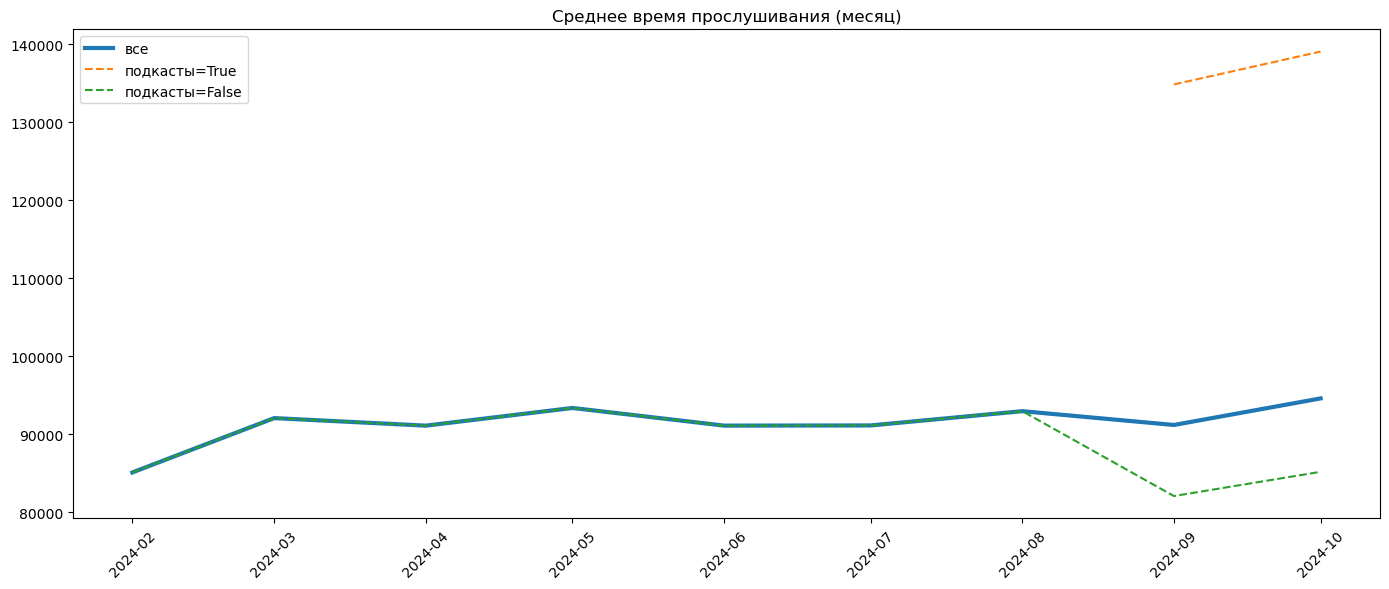

In [43]:
# месяц
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(monthly_listen_time_all.index, monthly_listen_time_all.values, label='все', linewidth=3)
for seg in [True, False]:
    sub = monthly_listen_time_seg.xs(seg, level='listened_podcast')
    ax.plot(sub.index, sub.values, label=f'подкасты={seg}', linestyle='--')
ax.set_title('Среднее время прослушивания (месяц)')
ax.legend()
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [44]:
# 2. Среднее число item_id на пользователя
# уникальные item_id (показывает разнообразие контента)
# неделя все
weekly_items_unique_all = df_week.groupby(['week', 'uid'])['item_id'].nunique().groupby('week').mean()
weekly_items_unique_all

week
2024-01-15    134.139529
2024-01-22    133.240301
2024-01-29    136.248206
2024-02-05    133.078297
2024-02-12    133.711451
2024-02-19    130.302775
2024-02-26    138.092768
2024-03-04    134.957050
2024-03-11    140.577039
2024-03-18    137.621928
2024-03-25    136.438784
2024-04-01    139.491364
2024-04-08    141.501501
2024-04-15    137.512744
2024-04-22    138.540720
2024-04-29    133.121627
2024-05-06    136.693455
2024-05-13    140.171926
2024-05-20    140.456781
2024-05-27    138.016177
2024-06-03    139.429184
2024-06-10    138.124300
2024-06-17    134.594216
2024-06-24    137.782182
2024-07-01    135.766480
2024-07-08    136.949008
2024-07-15    134.869442
2024-07-22    135.183451
2024-07-29    135.847478
2024-08-05    136.276499
2024-08-12    139.515604
2024-08-19    139.802135
2024-08-26    137.863799
2024-09-02    136.949885
2024-09-09    138.293689
2024-09-16    137.841743
2024-09-23    136.041127
2024-09-30    137.644802
2024-10-07    137.893251
2024-10-14    135.77

In [45]:
# неделя по сегментам
weekly_items_unique_seg = df_week.groupby(['week', 'listened_podcast', 'uid'])['item_id'].nunique().groupby(['week', 'listened_podcast']).mean()
weekly_items_unique_seg

week        listened_podcast
2024-01-15  False               134.139529
2024-01-22  False               133.240301
2024-01-29  False               136.248206
2024-02-05  False               133.078297
2024-02-12  False               133.711451
2024-02-19  False               130.302775
2024-02-26  False               138.092768
2024-03-04  False               134.957050
2024-03-11  False               140.577039
2024-03-18  False               137.621928
2024-03-25  False               136.438784
2024-04-01  False               139.491364
2024-04-08  False               141.501501
2024-04-15  False               137.512744
2024-04-22  False               138.540720
2024-04-29  False               133.121627
2024-05-06  False               136.693455
2024-05-13  False               140.171926
2024-05-20  False               140.456781
2024-05-27  False               138.016177
2024-06-03  False               139.429184
2024-06-10  False               138.124300
2024-06-17  False        

In [46]:
# месяц все
monthly_items_unique_all = df_month.groupby(['month', 'uid'])['item_id'].nunique().groupby('month').mean()
monthly_items_unique_all

month
2024-02-01    344.792980
2024-03-01    373.309919
2024-04-01    361.788794
2024-05-01    365.561257
2024-06-01    359.373220
2024-07-01    358.648597
2024-08-01    363.654284
2024-09-01    363.524720
2024-10-01    376.625141
Name: item_id, dtype: float64

In [47]:
# месяц по сегментам
monthly_items_unique_seg = df_month.groupby(['month', 'listened_podcast', 'uid'])['item_id'].nunique().groupby(['month', 'listened_podcast']).mean()
monthly_items_unique_seg

month       listened_podcast
2024-02-01  False               344.792980
2024-03-01  False               373.309919
2024-04-01  False               361.788794
2024-05-01  False               365.561257
2024-06-01  False               359.373220
2024-07-01  False               358.648597
2024-08-01  False               363.654284
2024-09-01  False               335.294444
            True                498.786331
2024-10-01  False               344.680455
            True                527.581877
Name: item_id, dtype: float64

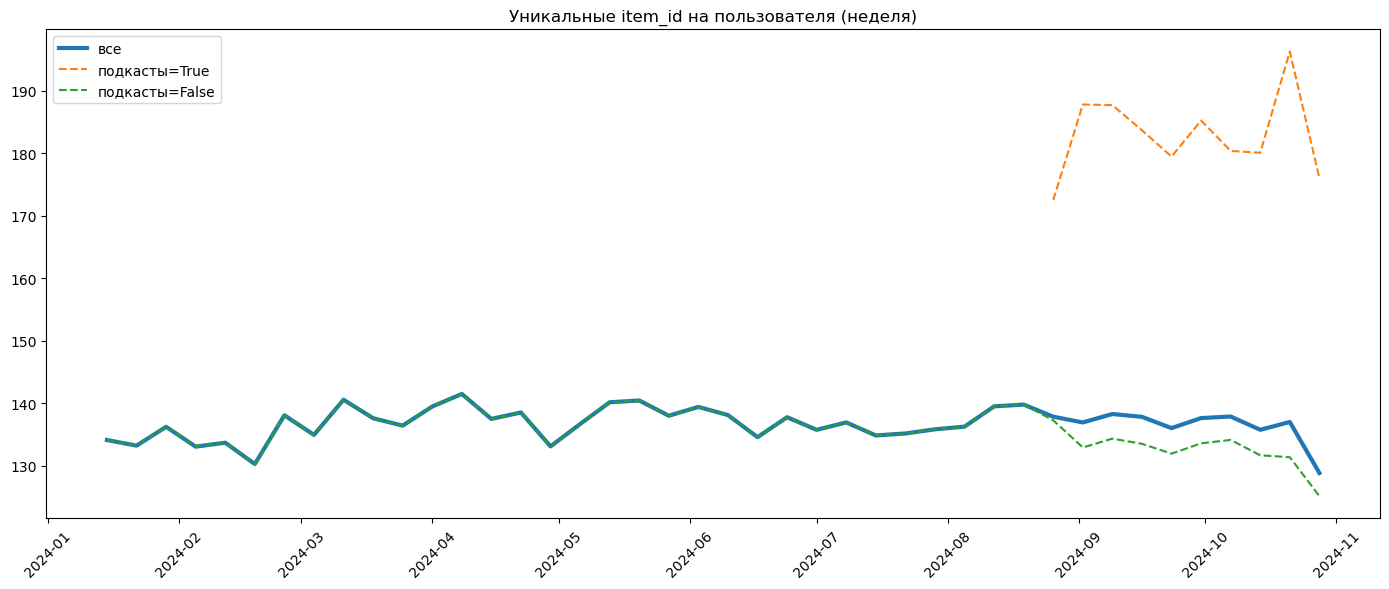

In [48]:
# График - уникальные item_id, неделя
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(weekly_items_unique_all.index, weekly_items_unique_all.values, label='все', linewidth=3)
for seg in [True, False]:
    sub = weekly_items_unique_seg.xs(seg, level='listened_podcast')
    ax.plot(sub.index, sub.values, label=f'подкасты={seg}', linestyle='--')
ax.set_title('Уникальные item_id на пользователя (неделя)')
ax.legend()
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

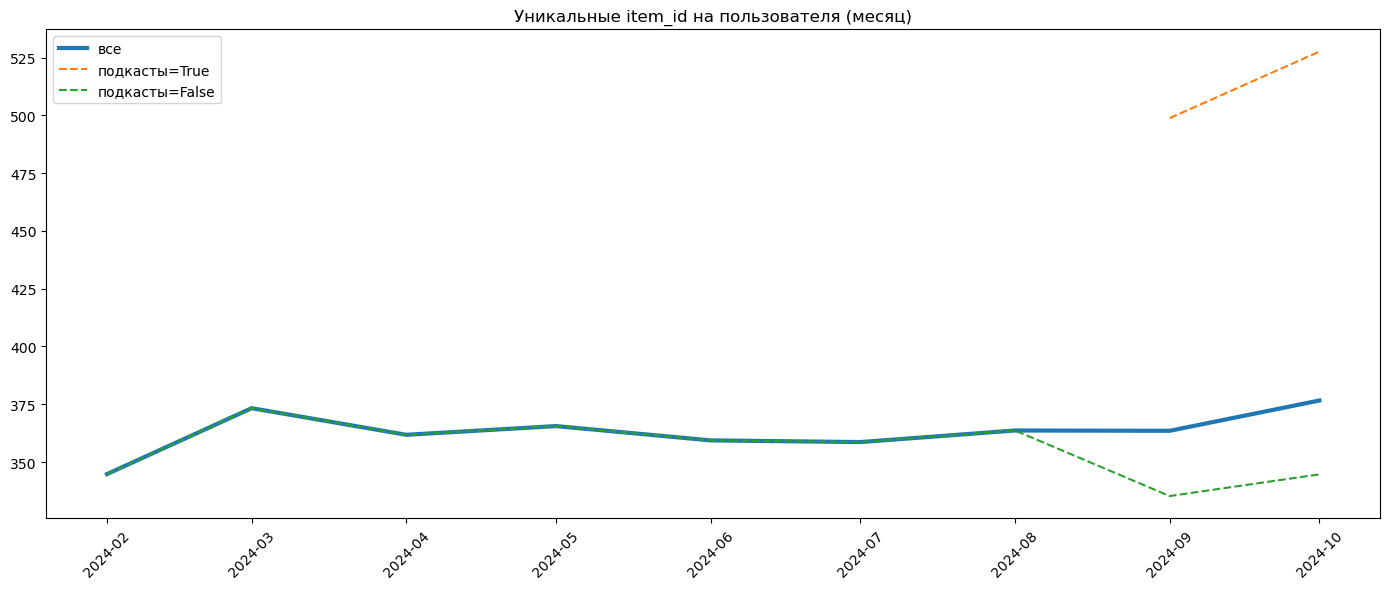

In [49]:
# График - уникальные item_id, месяц
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(monthly_items_unique_all.index, monthly_items_unique_all.values, label='все', linewidth=3)
for seg in [True, False]:
    sub = monthly_items_unique_seg.xs(seg, level='listened_podcast')
    ax.plot(sub.index, sub.values, label=f'подкасты={seg}', linestyle='--')
ax.set_title('Уникальные item_id на пользователя (месяц)')
ax.legend()
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [50]:
# все item_id (интенсивность)
weekly_items_all = df_week.groupby(['week', 'uid']).size().groupby('week').mean()
weekly_items_seg = df_week.groupby(['week', 'listened_podcast', 'uid']).size().groupby(['week', 'listened_podcast']).mean()

monthly_items_all = df_month.groupby(['month', 'uid']).size().groupby('month').mean()
monthly_items_seg = df_month.groupby(['month', 'listened_podcast', 'uid']).size().groupby(['month', 'listened_podcast']).mean()

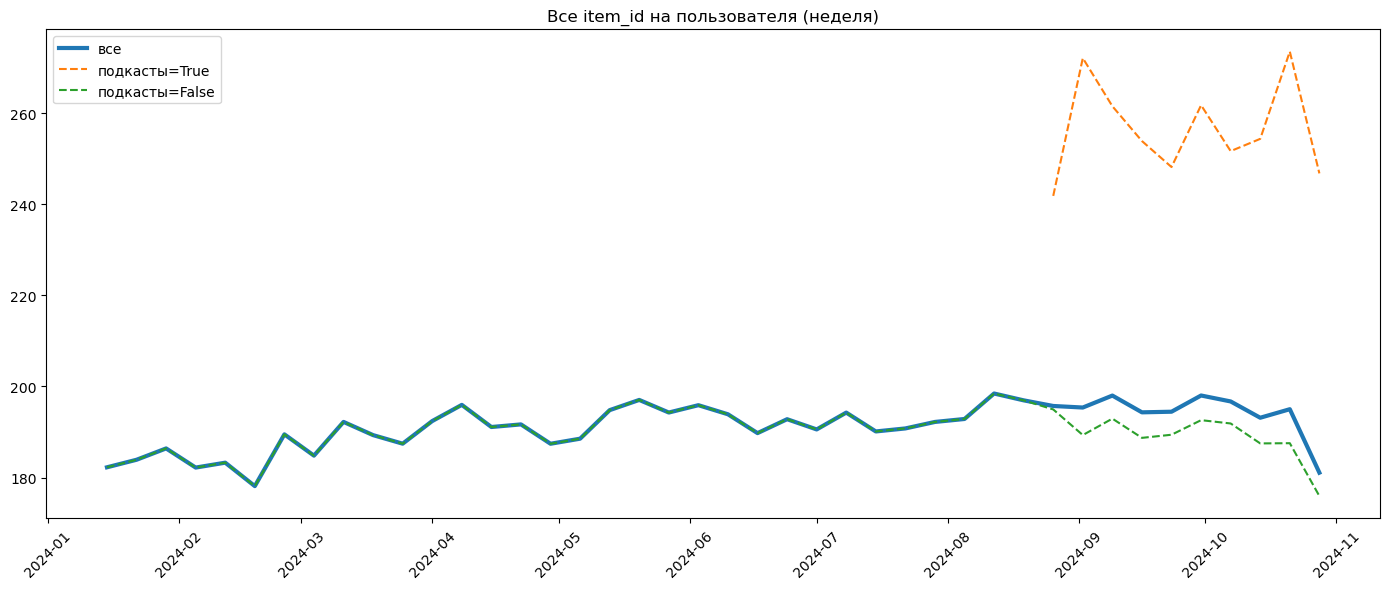

In [51]:
# График - все item_id, неделя
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(weekly_items_all.index, weekly_items_all.values, label='все', linewidth=3)
for seg in [True, False]:
    sub = weekly_items_seg.xs(seg, level='listened_podcast')
    ax.plot(sub.index, sub.values, label=f'подкасты={seg}', linestyle='--')
ax.set_title('Все item_id на пользователя (неделя)')
ax.legend()
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

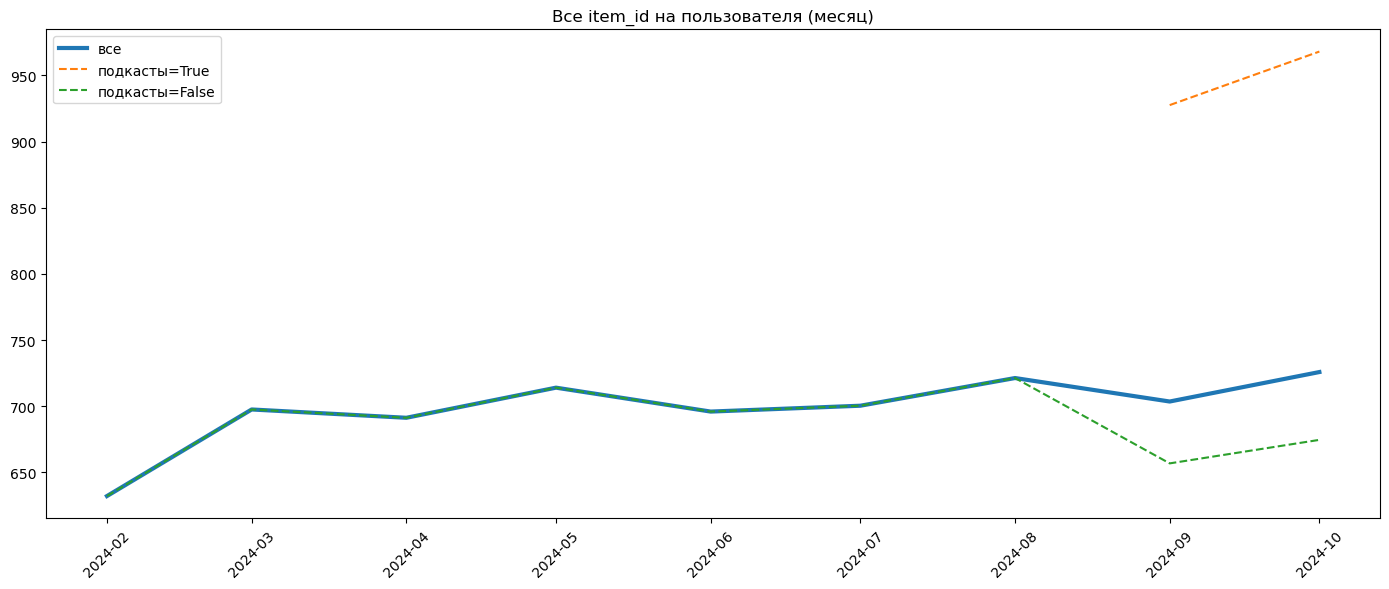

In [52]:
# График  все item_id, месяц
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(monthly_items_all.index, monthly_items_all.values, label='все', linewidth=3)
for seg in [True, False]:
    sub = monthly_items_seg.xs(seg, level='listened_podcast')
    ax.plot(sub.index, sub.values, label=f'подкасты={seg}', linestyle='--')
ax.set_title('Все item_id на пользователя (месяц)')
ax.legend()
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [54]:
# 3. Доля премиум-подписчиков (активная подписка)
# активная: start_date <= конец периода и (end_date is nat или end_date > начало периода)
weekly_subs = []
for w in sorted(df_week['week'].unique()):
    w_end = w + timedelta(days=6)
    active = df_music_subs[
        (df_music_subs['start_date'] <= w_end) &
        ((df_music_subs['end_date'].isna()) | (df_music_subs['end_date'] > w))
    ]['uid'].nunique()
    total_users = df_week[df_week['week'] == w]['uid'].nunique()
    weekly_subs.append(active/total_users)
weekly_subs = pd.Series(weekly_subs, index=sorted(df_week['week'].unique()))

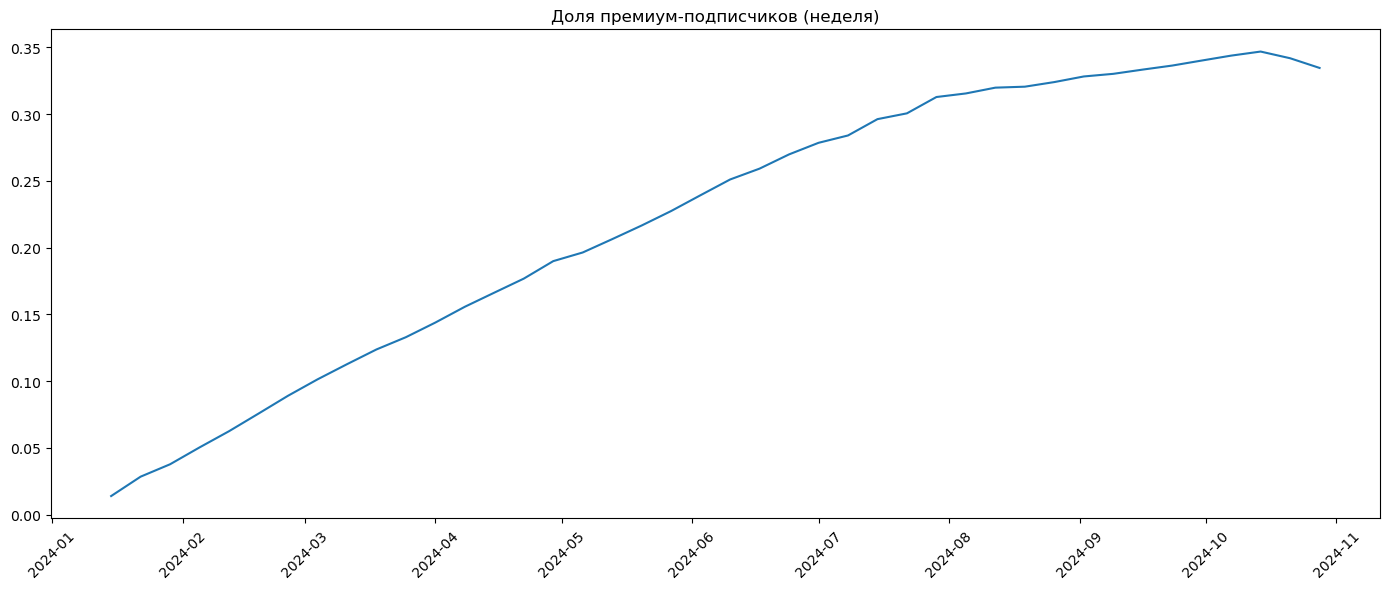

In [55]:
# График — неделя
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(weekly_subs.index, weekly_subs.values)
ax.set_title('Доля премиум-подписчиков (неделя)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [56]:
monthly_subs = []
for m in sorted(df_month['month'].unique()):
    m_end = m + pd.offsets.MonthEnd(0)
    active = df_music_subs[
        (df_music_subs['start_date'] <= m_end) &
        ((df_music_subs['end_date'].isna()) | (df_music_subs['end_date'] > m))
    ]['uid'].nunique()
    total_users = df_month[df_month['month'] == m]['uid'].nunique()
    monthly_subs.append(active/total_users)
monthly_subs = pd.Series(monthly_subs, index=sorted(df_month['month'].unique()))

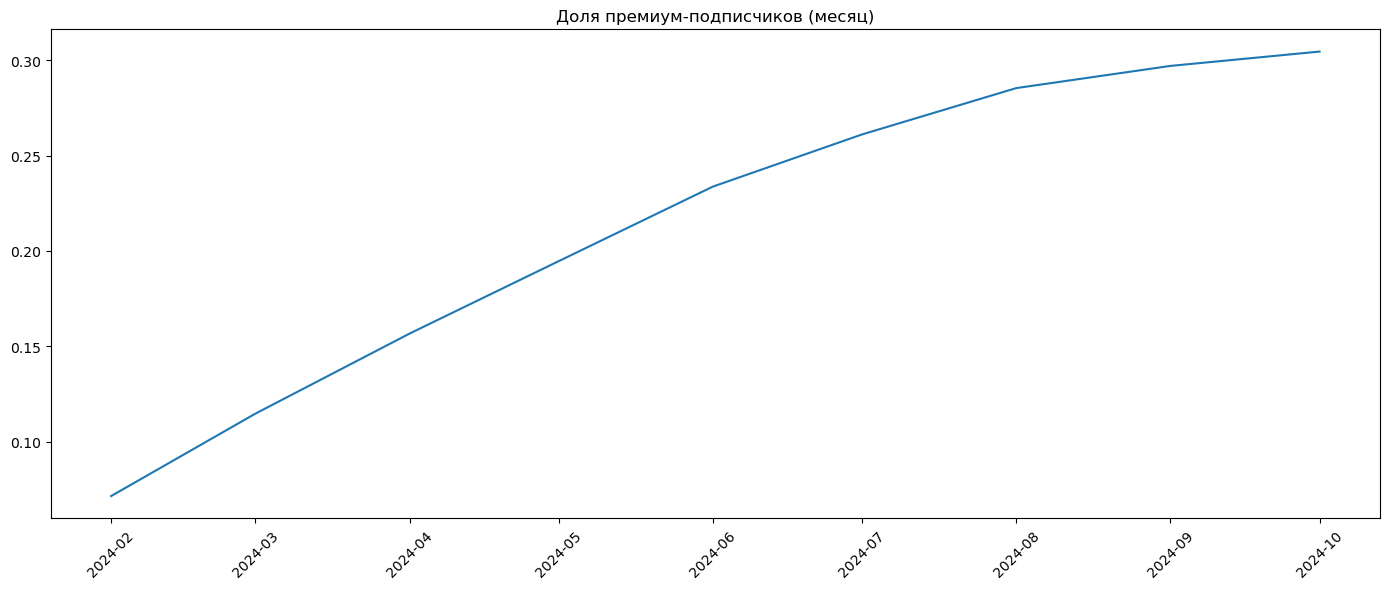

In [57]:
# График - месяц
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(monthly_subs.index, monthly_subs.values)
ax.set_title('Доля премиум-подписчиков (месяц)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [58]:
# 4. Доля дослушанных до конца (не пользовательская метрика)
df_week['completed'] = df_week['played_ratio_pct'] == 100
df_month['completed'] = df_month['played_ratio_pct'] == 100
weekly_completed_all = df_week.groupby('week')['completed'].mean()
weekly_completed_all

week
2024-01-15    0.547456
2024-01-22    0.541428
2024-01-29    0.539358
2024-02-05    0.544148
2024-02-12    0.549772
2024-02-19    0.533033
2024-02-26    0.537698
2024-03-04    0.536697
2024-03-11    0.518138
2024-03-18    0.530784
2024-03-25    0.525642
2024-04-01    0.526819
2024-04-08    0.535617
2024-04-15    0.541070
2024-04-22    0.530694
2024-04-29    0.528418
2024-05-06    0.525244
2024-05-13    0.532271
2024-05-20    0.534106
2024-05-27    0.535494
2024-06-03    0.544827
2024-06-10    0.542241
2024-06-17    0.538741
2024-06-24    0.531601
2024-07-01    0.536461
2024-07-08    0.533295
2024-07-15    0.530308
2024-07-22    0.535540
2024-07-29    0.531418
2024-08-05    0.536021
2024-08-12    0.530195
2024-08-19    0.525068
2024-08-26    0.529934
2024-09-02    0.534253
2024-09-09    0.522856
2024-09-16    0.525382
2024-09-23    0.526225
2024-09-30    0.523280
2024-10-07    0.520450
2024-10-14    0.523782
2024-10-21    0.525669
2024-10-28    0.536398
Name: completed, dtype: float

In [59]:
weekly_completed_type = df_week.groupby(['week', 'content_type'])['completed'].mean()
weekly_completed_type

week        content_type
2024-01-15  music           0.547456
2024-01-22  music           0.541428
2024-01-29  music           0.539358
2024-02-05  music           0.544148
2024-02-12  music           0.549772
2024-02-19  music           0.533033
2024-02-26  music           0.537698
2024-03-04  music           0.536697
2024-03-11  music           0.518138
2024-03-18  music           0.530784
2024-03-25  music           0.525642
2024-04-01  music           0.526819
2024-04-08  music           0.535617
2024-04-15  music           0.541070
2024-04-22  music           0.530694
2024-04-29  music           0.528418
2024-05-06  music           0.525244
2024-05-13  music           0.532271
2024-05-20  music           0.534106
2024-05-27  music           0.535494
2024-06-03  music           0.544827
2024-06-10  music           0.542241
2024-06-17  music           0.538741
2024-06-24  music           0.531601
2024-07-01  music           0.536461
2024-07-08  music           0.533295
2024-07-15  m

In [60]:
monthly_completed_all = df_month.groupby('month')['completed'].mean()
monthly_completed_all

month
2024-02-01    0.542239
2024-03-01    0.527678
2024-04-01    0.532006
2024-05-01    0.532834
2024-06-01    0.538479
2024-07-01    0.533776
2024-08-01    0.530753
2024-09-01    0.525602
2024-10-01    0.525981
Name: completed, dtype: float64

In [62]:
monthly_completed_type = df_month.groupby(['month', 'content_type'])['completed'].mean()
monthly_completed_type

month       content_type
2024-02-01  music           0.542239
2024-03-01  music           0.527678
2024-04-01  music           0.532006
2024-05-01  music           0.532834
2024-06-01  music           0.538479
2024-07-01  music           0.533776
2024-08-01  music           0.530753
2024-09-01  music           0.526010
            podcast         0.398173
2024-10-01  music           0.526622
            podcast         0.356913
Name: completed, dtype: float64

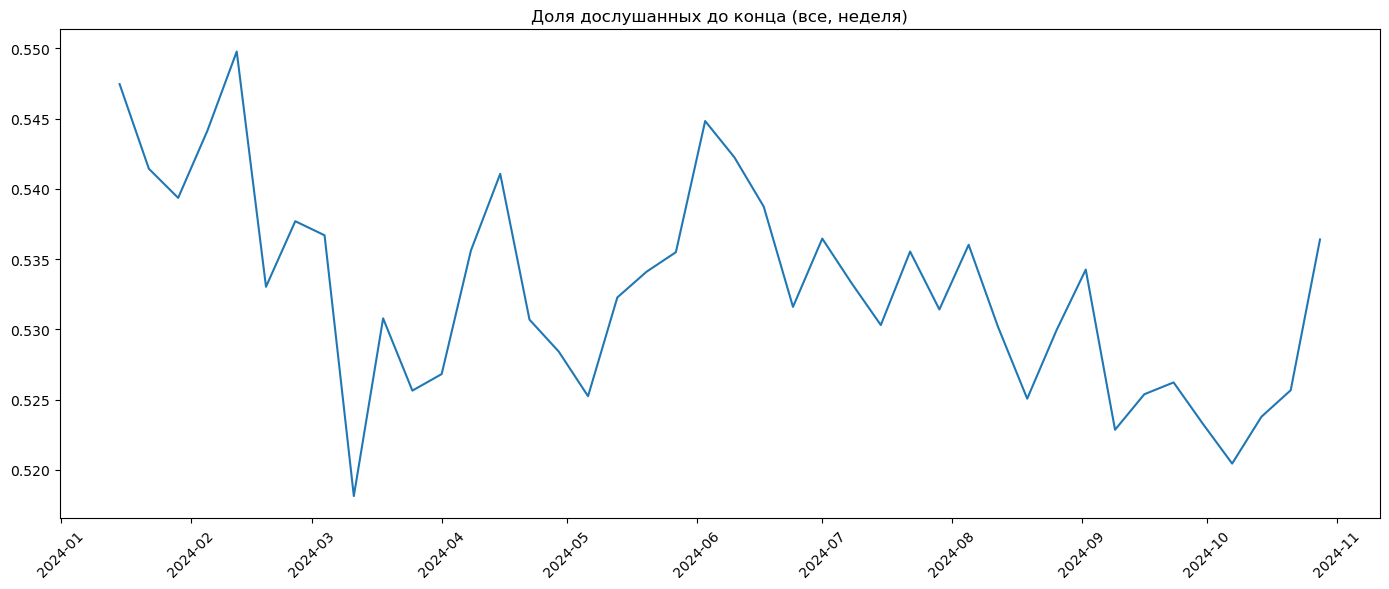

In [63]:
# График — все, неделя
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(weekly_completed_all.index, weekly_completed_all.values)
ax.set_title('Доля дослушанных до конца (все, неделя)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

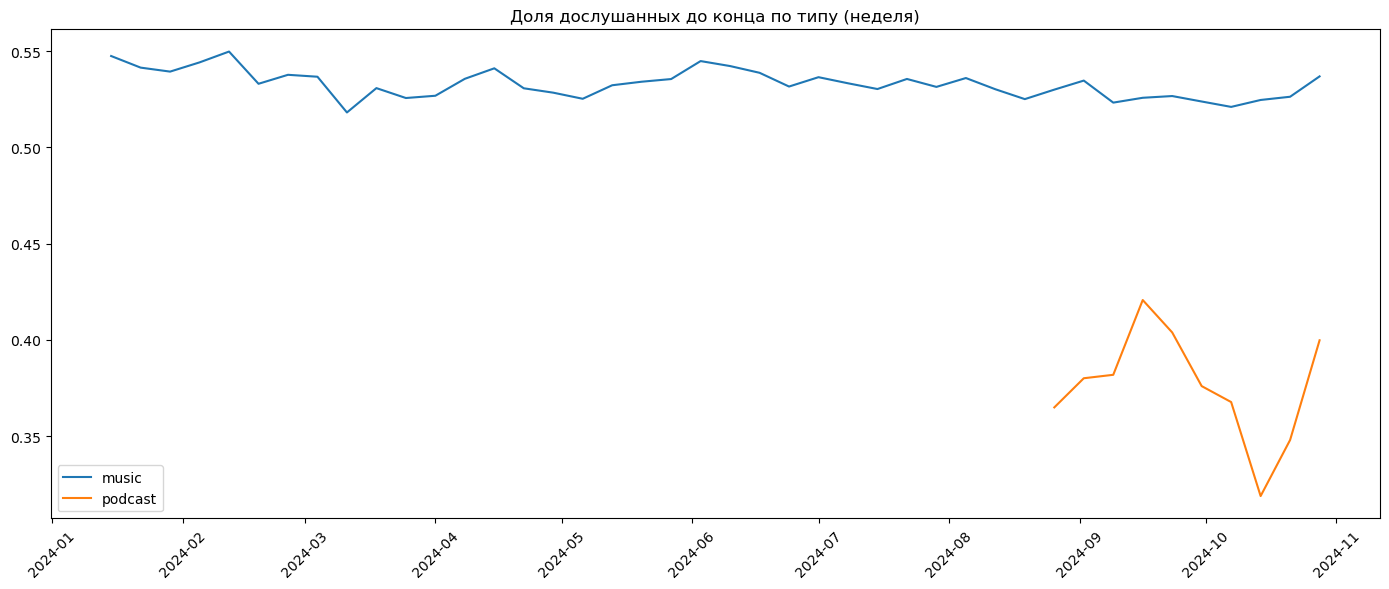

In [64]:
# График - по типам, неделя
fig, ax = plt.subplots(figsize=(14, 6))
for ct in weekly_completed_type.index.get_level_values('content_type').unique():
    sub = weekly_completed_type.xs(ct, level='content_type')
    ax.plot(sub.index, sub.values, label=ct)
ax.set_title('Доля дослушанных до конца по типу (неделя)')
ax.legend()
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

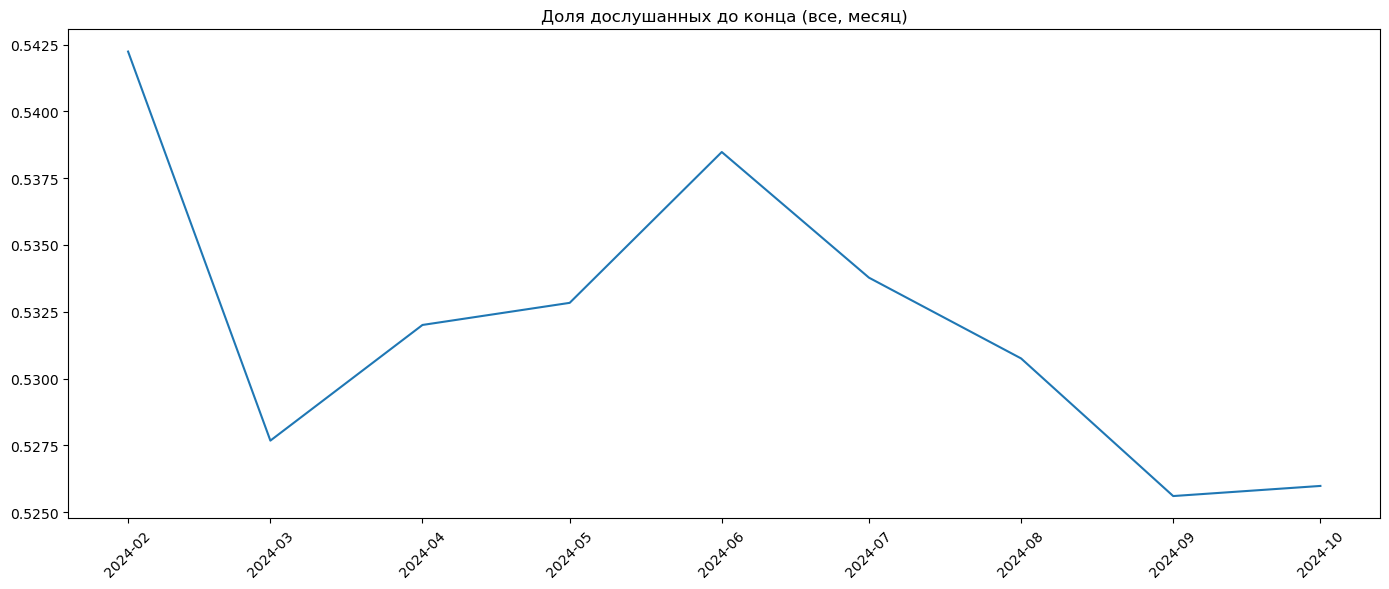

In [65]:
# График - все, месяц
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(monthly_completed_all.index, monthly_completed_all.values)
ax.set_title('Доля дослушанных до конца (все, месяц)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

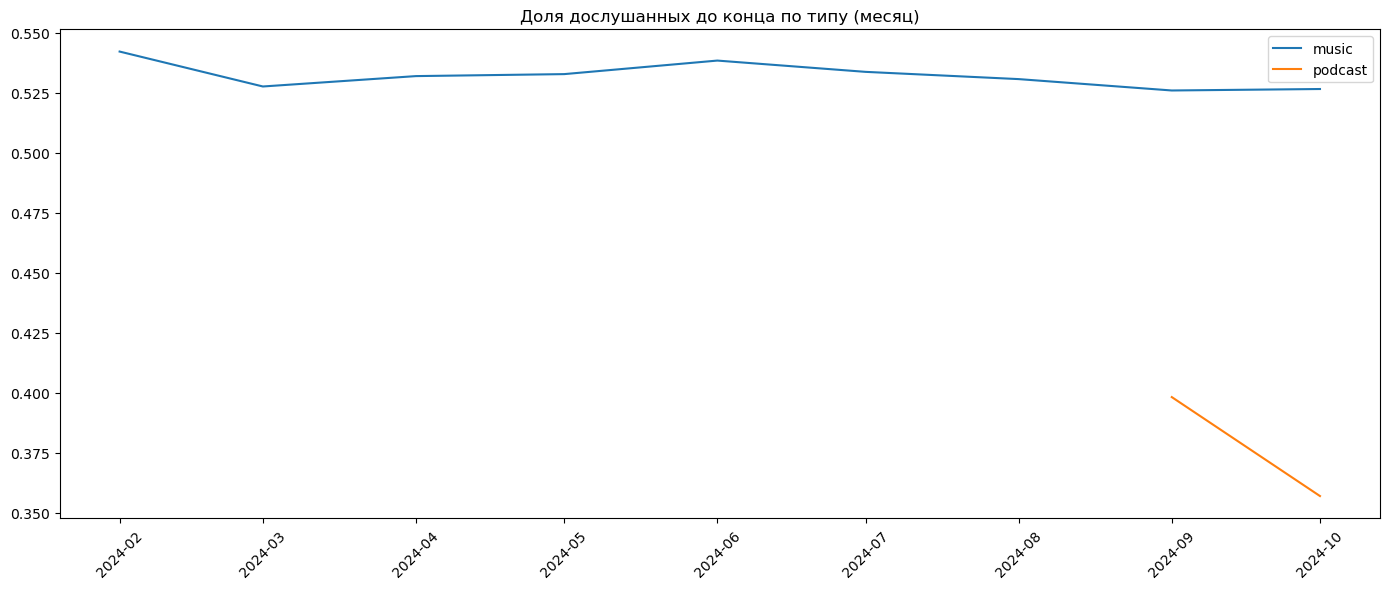

In [66]:
# График - по типам, месяц
fig, ax = plt.subplots(figsize=(14, 6))
for ct in monthly_completed_type.index.get_level_values('content_type').unique():
    sub = monthly_completed_type.xs(ct, level='content_type')
    ax.plot(sub.index, sub.values, label=ct)
ax.set_title('Доля дослушанных до конца по типу (месяц)')
ax.legend()
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


**Есть ли выраженный тренд?**
По доле премиум-подписчиков, она растет весь год. Остальные метрики до сентября стабильны, а после запуска подкастов дают всплеск исключительно за счет сегмента "подкасты=True"

**Изменилась ли метрика после запуска подкастов?**
У сегмента музыки метрики практически не изменились, а вот у подкастов - да (время прослушивания, разнообразие item_id). Общая метрика растет только за счет нового сегмента

**Отличается ли сегмент с подкастами от "только музыка"?**
Да, сегмент с подкастами слушает больше по времени, разнообразнее по уникальным item_id и интенсивнее по общему числу прослушиваний.
Но! Возможно это не подкасты делают пользователей более вовлеченными, а изначально вовлеченные пользователи идут пробовать подкасты. Причина/следствие - это к A/B

**Есть ли отличия между типами контента?**
Да. Музыка дослушивается до конца чуть больше 50%, подкасты меньше, примерно 35–42%. Думаю, связано с тем. что по длительности подкасты длиннее, их сложнее дослушать, поэтому метрика ниже

### 5. Метрики продукта (шаг 2)  — 2 балла

Рассчитайте и визуализируйте:
1) D1, D7, D30 retention по всем пользователям. Когорты агрегируйте по неделям т.к. из-за низкого числа новичков на дневном разрезе визуализации слишком шумные.
2) D30 retention для сегментов пользователей в разрезе — сделали / не сделали взаимодействие с подкастами на промежутке до 30 дня. Когорты агрегируйте по неделям.
3) D7 retention для сегментов пользователей в разрезе — сделали / не сделали взаимодействие с подкастами на промежутке до 7 дня. Когорты агрегируйте по месяцам.

Для наглядности будет полезно нарисовать на одном графике как посегментную, так и общую динамику (для этого можете достроить D7 retention для всех пользователей с помесячной агрегацией).

Сделайте выводы:
- Есть ли выраженный тренд?
- Изменилась ли метрика после запуска подкастов?
- Отличается ли метрика сегмента, взаимодействовавшего с подкастами, от тех, кто слушал только музыку? (будьте аккуратны с выводами в этом пункте, мы не проверяем изменение на каузальность, поэтому не можем быть уверены где причина, а где следствие)

*За взаимодействие с подкастами давайте считать только прослушивание >= 30% или более 2х минут контента*

In [67]:
# your code is here
# первая дата
first_date = df_music_logs.groupby('uid')['date'].min().reset_index()
first_date.columns = ['uid', 'first_date']

df_music_logs = df_music_logs.merge(first_date, on='uid', how='left')

In [68]:
# дни с первой даты
df_music_logs['days_since_first'] = (pd.to_datetime(df_music_logs['date']) - pd.to_datetime(df_music_logs['first_date'])).dt.days

In [69]:
# когорты: по неделям и по месяцам первой даты
df_music_logs['cohort_week'] = pd.to_datetime(df_music_logs['first_date']).dt.to_period('W').dt.start_time
df_music_logs['cohort_month'] = pd.to_datetime(df_music_logs['first_date']).dt.to_period('M').dt.start_time

In [70]:
print('Максимальный возраст пользователя (дней):', df_music_logs['days_since_first'].max())

Максимальный возраст пользователя (дней): 301


In [71]:
# played_seconds
df_music_logs['played_seconds'] = df_music_logs['track_length_seconds'] * df_music_logs['played_ratio_pct']/100

# флаг взаимодействия
df_music_logs['podcast_interaction'] = (
    (df_music_logs['content_type'] == 'podcast') &
    (
        (df_music_logs['played_ratio_pct'] >= 30) |
        (df_music_logs['played_seconds'] > 120)
    )
)

In [72]:
# флаг: слушал ли подкасты в первые 7 дней
podcast_7d = df_music_logs[
    (df_music_logs['podcast_interaction']) &
    (df_music_logs['days_since_first'] <= 7)
].groupby('uid')['podcast_interaction'].max().reset_index()
podcast_7d.columns = ['uid', 'podcast_7d']

In [73]:
# флаг: слушал ли в первые 30 дней
podcast_30d = df_music_logs[
    (df_music_logs['podcast_interaction']) &
    (df_music_logs['days_since_first'] <= 30)
].groupby('uid')['podcast_interaction'].max().reset_index()
podcast_30d.columns = ['uid', 'podcast_30d']

In [74]:
# присоединяю
df_music_logs = df_music_logs.merge(podcast_7d, on='uid', how='left')
df_music_logs = df_music_logs.merge(podcast_30d, on='uid', how='left')

df_music_logs['podcast_7d'] = df_music_logs['podcast_7d'].fillna(False)
df_music_logs['podcast_30d'] = df_music_logs['podcast_30d'].fillna(False)

C:\Users\user\AppData\Local\Temp\ipykernel_39328\907498559.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_music_logs['podcast_7d'] = df_music_logs['podcast_7d'].fillna(False)
C:\Users\user\AppData\Local\Temp\ipykernel_39328\907498559.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_music_logs['podcast_30d'] = df_music_logs['podcast_30d'].fillna(False)


1. D1, D7, D30 retention по всем пользователям. Когорты агрегируйте по неделям т.к. из-за низкого числа новичков на дневном разрезе визуализации слишком шумные.

In [75]:
max_date = pd.to_datetime(df_music_logs['date']).max()

In [76]:
# размер когорты
cohort_size_week = df_music_logs.groupby('cohort_week')['uid'].nunique()

In [77]:
# D1, D7, D30
d1 = df_music_logs[df_music_logs['days_since_first'] == 1].groupby('cohort_week')['uid'].nunique()/cohort_size_week
d7 = df_music_logs[df_music_logs['days_since_first'] == 7].groupby('cohort_week')['uid'].nunique()/cohort_size_week
d30 = df_music_logs[df_music_logs['days_since_first'] == 30].groupby('cohort_week')['uid'].nunique()/cohort_size_week

# обрезаю неполные когорты
d1 = d1[d1.index <= max_date - pd.Timedelta(days=1)]
d7 = d7[d7.index <= max_date - pd.Timedelta(days=7)]
d30 = d30[d30.index <= max_date - pd.Timedelta(days=30)]

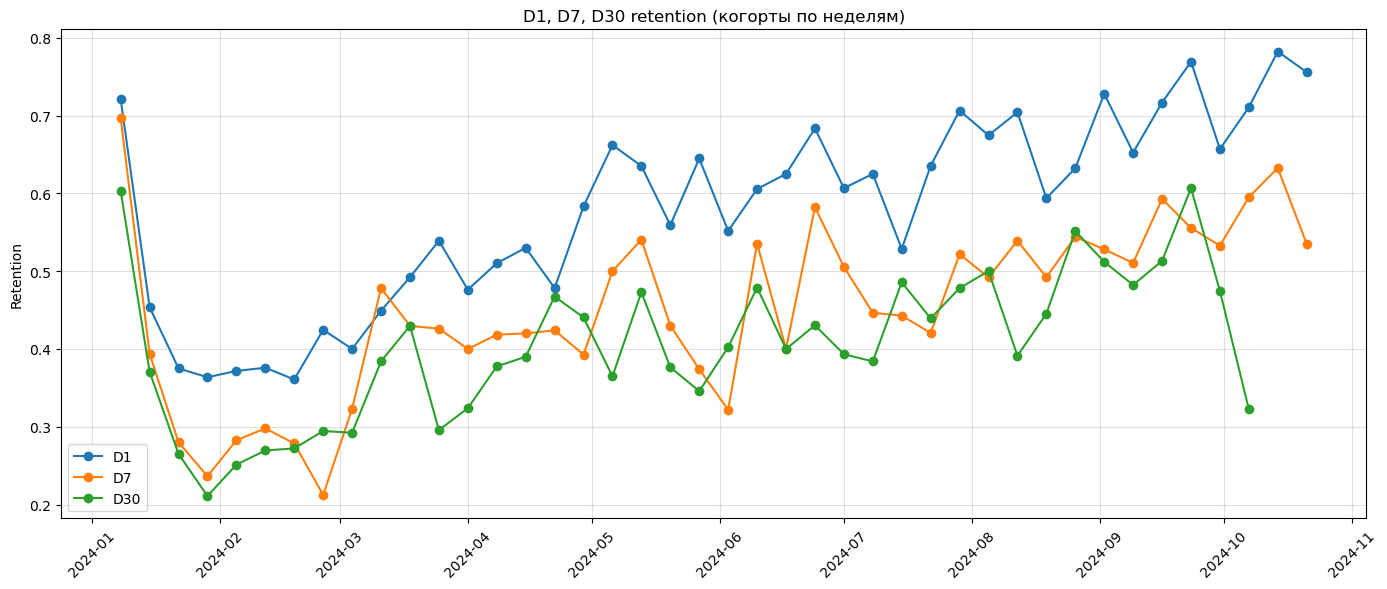

In [78]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(d1.index, d1.values, label='D1', marker='o')
ax.plot(d7.index, d7.values, label='D7', marker='o')
ax.plot(d30.index, d30.values, label='D30', marker='o')
ax.set_title('D1, D7, D30 retention (когорты по неделям)')
ax.set_ylabel('Retention')
ax.legend()
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

2. D30 retention для сегментов пользователей в разрезе — сделали / не сделали взаимодействие с подкастами на промежутке до 30 дня. Когорты агрегируйте по неделям.

In [79]:
# размер когорты по сегментам
cohort_size_seg_30 = df_music_logs.groupby(['cohort_week', 'podcast_30d'])['uid'].nunique()

In [80]:
# D30 по сегментам
d30_seg = df_music_logs[df_music_logs['days_since_first'] == 30].groupby(['cohort_week', 'podcast_30d'])['uid'].nunique()/cohort_size_seg_30

In [81]:
# обрезаю неполные когорты
d30_seg = d30_seg[d30_seg.index.get_level_values('cohort_week') <= max_date - pd.Timedelta(days=30)]

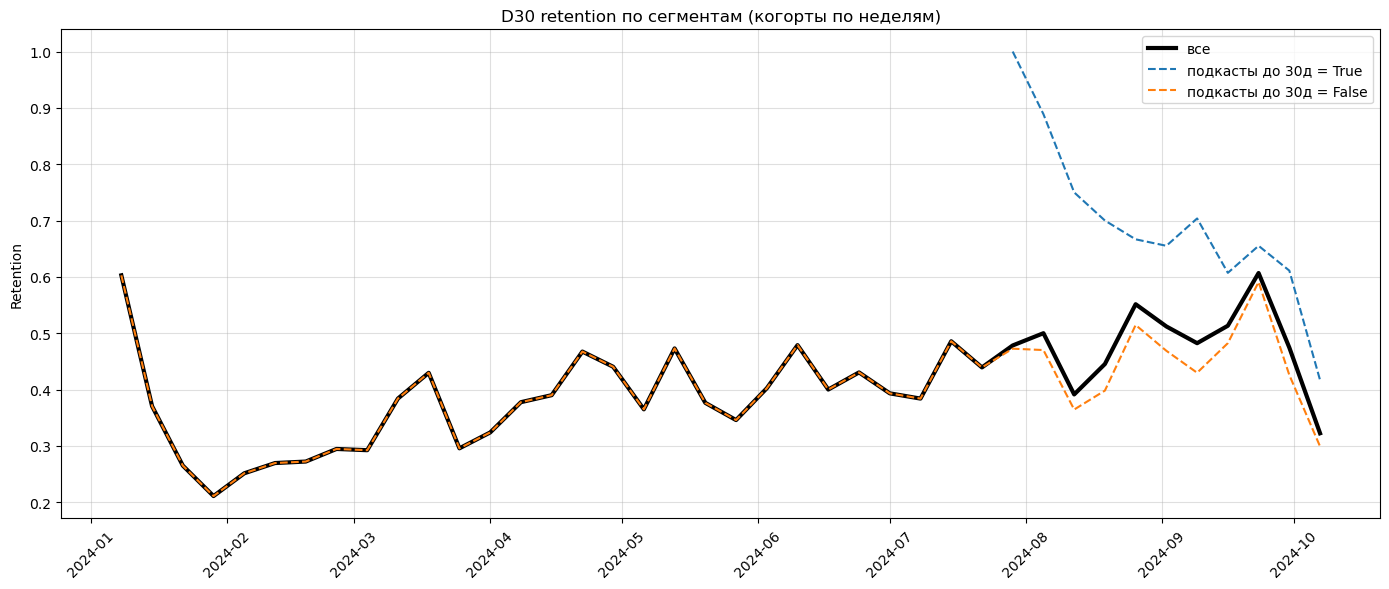

In [82]:
fig, ax = plt.subplots(figsize=(14, 6))

# общая динамика D30
d30_plot = d30[d30.index <= max_date - pd.Timedelta(days=30)]
ax.plot(d30_plot.index, d30_plot.values, label='все', linewidth=3, color='black')

# по сегментам
for seg in [True, False]:
    if seg in d30_seg.index.get_level_values('podcast_30d'):
        sub = d30_seg.xs(seg, level='podcast_30d')
        ax.plot(sub.index, sub.values, label=f'подкасты до 30д = {seg}', linestyle='--')

ax.set_title('D30 retention по сегментам (когорты по неделям)')
ax.set_ylabel('Retention')
ax.legend()
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

3. D7 retention для сегментов пользователей в разрезе — сделали / не сделали взаимодействие с подкастами на промежутке до 7 дня. Когорты агрегируйте по месяцам.

In [83]:
# размер когорты по сегментам (месяцы)
cohort_size_seg_7 = df_music_logs.groupby(['cohort_month', 'podcast_7d'])['uid'].nunique()

In [84]:
# D7 по сегментам (месяцы)
d7_seg = df_music_logs[df_music_logs['days_since_first'] == 7].groupby(['cohort_month', 'podcast_7d'])['uid'].nunique()/cohort_size_seg_7

In [85]:
# общая динамика D7 с помесячной агрегацией
cohort_size_month = df_music_logs.groupby('cohort_month')['uid'].nunique()
d7_month = df_music_logs[df_music_logs['days_since_first'] == 7].groupby('cohort_month')['uid'].nunique()/cohort_size_month

In [86]:
# обрезаю неполные когорты
d7_month = d7_month[d7_month.index <= max_date - pd.Timedelta(days=7)]
d7_seg = d7_seg[d7_seg.index.get_level_values('cohort_month') <= max_date - pd.Timedelta(days=7)]

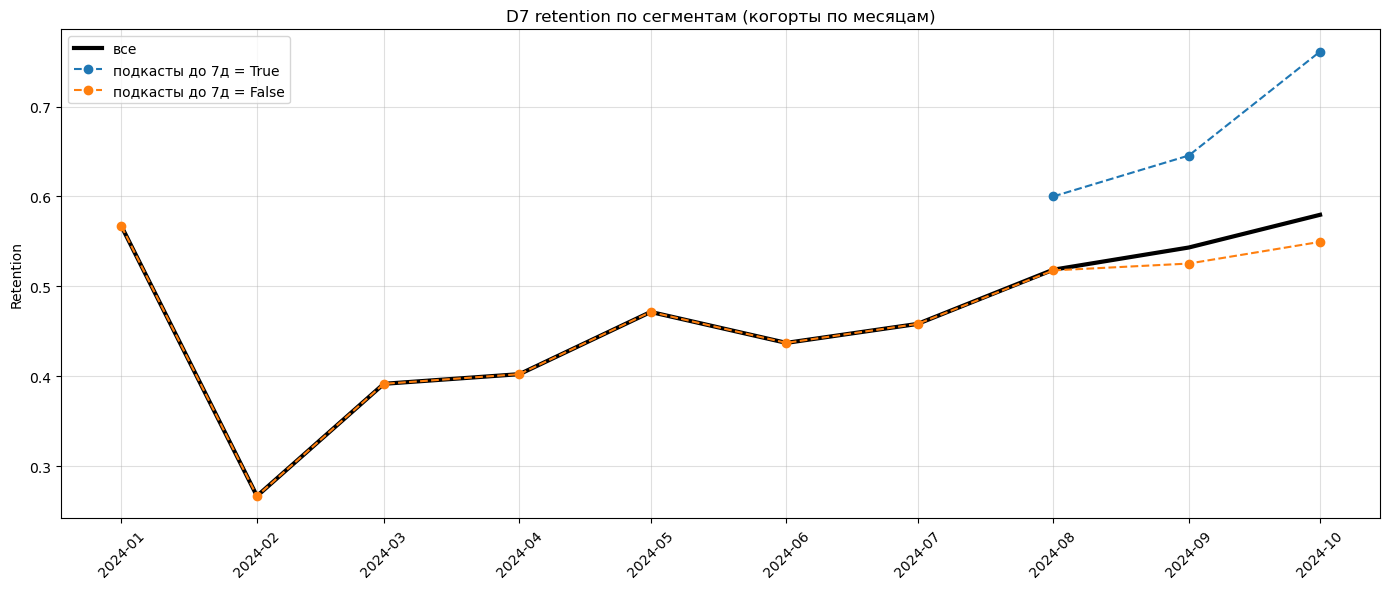

In [87]:
fig, ax = plt.subplots(figsize=(14, 6))

# общая динамика
ax.plot(d7_month.index, d7_month.values, label='все', linewidth=3, color='black')

# по сегментам
for seg in [True, False]:
    if seg in d7_seg.index.get_level_values('podcast_7d'):
        sub = d7_seg.xs(seg, level='podcast_7d')
        ax.plot(sub.index, sub.values, label=f'подкасты до 7д = {seg}', linestyle='--', marker='o')

ax.set_title('D7 retention по сегментам (когорты по месяцам)')
ax.set_ylabel('Retention')
ax.legend()
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

**Есть ли выраженный тренд?**
У всех метрик retention наблюдается восходящий тренд. D1, D7, D30 растут от когорты к когорте, то есть улучшается удержание

**Изменилась ли метрика после запуска подкастов?**
Да, но не сразу. До августа сегменты почти не отличались, подкасты еще не были раскатаны на большую часть пользователей. После августа D7 и D30 retention у сегмента подкасты резко идут вверх. Общий retention также растет, но медленнее

**Отличается ли метрика сегмента, взаимодействовавшего с подкастами, от тех, кто слушал только музыку?**
Да, удержание у подкастов выше.Возможно подкасты действительно повышают удержание. Но как я писала в задании выще, может быть такое, что в сегмент подкастов попадают изначально более вовлеченные пользователи, открытые к новым формататм. Поэтому опять же мы не можем сказать, что именно подкасты удерживают


### 6. Приоритизация метрик  — 2 балла

Составьте список всех метрик, которые были рассчитаны выше (не забудьте, что показатель, рассчитанный в разрезе сегмента — это отдельная метрика). Для простоты давайте ориентироваться только на недельную агрегацию.

1. Присвойте метрикам приоритеты P0-P3 по принципу (в этом пункте стройте приоритизацию на уровне всей компании):
   -  P0 — бизнес результат;
   -  P1 — метрики продукта, напрямую аффектящие бизнес-результат (retention, product as a habit);
   -  P2 — метрики, отражающие взаимодействие пользователя с продуктом (user experience, user engagement) / таргет-метрики отдельных команд продукта;
   -  P3 — метрики стримов / опыт пользователя в рамках работы отдельных команд.
2. Пересоберите приоритеты только для команды подкастов, если цель развития подкастов — рост пользователей с подпиской. Обратите внимание, что вам не нужно отказываться от метрик, рассчитанных по всем пользователям (без сегментов) или для сегмента Music (полезно понимать, не каннибализируем ли мы основной тип контента). Скорее всего приоритеты изменятся только для посегментных метрик.
4. Представьте, что цель внедрения подкастов поменялась — теперь команда в первую очередь хочет задрайвить вовлеченность в продукт. Пересоберите приоритеты при необходимости (в данном пункте могут измениться приоритеты для метрик, рассчитанных по всем пользователям).

Для каждого из пунктов дайте краткое обоснование, почему вы присвоили приоритеты именно так.

# your answer is here
##ВСЕ МЕТРИКИ

**По всем пользователям:**
- DAU/WAU/MAU
- Новые премиум-подписчики (неделя)
- Проникновение подкастов (неделя)
- Среднее время прослушивания (все)
- Уникальные item_id (все)
- Все item_id (все)
- Доля премиум-подписчиков
- Доля дослушанных до конца (все)
- D1/D7/D30 retention (все)

**По сегментам (подкасты=True/False):**
- Среднее время прослушивания подкасты/музыка
- Уникальные item_id подкасты/музыка
- Все item_id подкасты/музыка
- Доля дослушанных до конца подкасты/музыка
- D7 retention подкасты/музыка
- D30 retention подкасты/музыка

### 1. Приоритеты на уровне всей компании

**P0 - бизнес результат:**
- Новые премиум-подписчики
  
Это деньги, все остальное для роста денег

**P1 - продуктовые, влияющие на бизнес:**
- DAU/WAU/MAU
- D1/D7/D30 retention
- Доля премиума в сегменте подкаст
- Проникновение подкастов (неделя)
  
Retention - это основа подписки, так как без удержания денег не будет.
Проникновение подкастов на этом уровне, так как показатель важен для нового продукта и еслм он не приживется, все остальное по подкастам не имеет смысла.

**P2 - взаимодействие и таргет-метрики команд:**
- Среднее время прослушивания
- ARPDAU, Stickiness
- Уникальные item_id
- Все item_id
- Доля дослушанных до конца
  
Это метрики вовлеченности. Они влияют на P1 (например, больше слушают, следовательно, выше retention), но сами по себе не являются бизнес-результатом

**P3 - метрики стримов и опыт внутри команд:**
- Посегментные метрики (музыка/подкаст)
  
Тут посегментные метрики, потому что на уровне компании они второстепенны

### 2. Приоритеты для команды подкастов (цель - рост пользователей с подпиской)

**P0:**
- Новые премиум-подписчики
- Доля премиум-подписчиков

**P1:**
- Проникновение подкастов
- D7 и D30 retention подкасты
- D7/D30 retention для всех

**P2:**
- Среднее время в сегменте подкасты
- Уникальные/все item_id в сегменте подкасты
- Доля дослушанных в сегменте подкасты
- DAU/WAU/MAU

**P3:**
- Метрики сегмента музыка

Здесь посегментные метрики подкастов поднялись выше, а музыки - ниже. 
Общие retention и проникновение остались в P1
На что ориентировалась при расстановке: подкаст-команда не может напрямую влиять деньги всей компании, но может двигать проникновение и retention своего сегмента 
При этом метрики только музыка оставила в P3, нужны только для проверки каннибализации, напрямую команда на них не влияет

### 3. Цель - вовлеченность

**P0:**
- Новые премиум подписчики

**P1:**
- DAU/WAU/MAU
- D1/D7/D30 retention все
- Проникновение подкастов
- Среднее время (подкасты)
- Все item_id (подкасты)

**P2:**
- Уникальные item_id
- Доля дослушанных
- Доля премиум-подписчиков

**P3:**
- Посегментные метрики

На что ориентировалась: на определение вовлеченности  - как часто и как глубоко пользуются продуктом. И вовлеченность измеряется частотой (DAU/WAU/MAU) и глубиной (среднее время, число item_id). Поэтому эти метрики вышли на P0, а деньги (доля премиум) ушли вниз